In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [ ]:
!gdown --id 1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn #Download File

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn
To: /content/Rakamin Bootcamp - Dataset - Promotion Dataset.csv
100% 35.5k/35.5k [00:00<00:00, 47.3MB/s]


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Rakamin Bootcamp - Dataset - Promotion Dataset.csv', sep = ';')
df.head()

,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible
0,EMP0001,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0.0
1,EMP0002,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0.0
2,EMP0003,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0.0
3,EMP0004,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0.0
4,EMP0005,41.0,NaN,4.0,64.0,57.0,16.0,59.0,Junior,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             1000 non-null   object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        951 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    float64
dtypes: float64(8), object(2)
memory usage: 78.3+ KB


# Handling Missing Value

In [ ]:
# Imputasi missing value dengan median pada Age, Years_at_Company, dan Training_Hours
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Years_at_Company'].fillna(df['Years_at_Company'].median(), inplace=True)
df['Training_Hours'].fillna(df['Training_Hours'].median(), inplace=True)

# Imputasi missing value dengan mean pada Performance_Score, Leadership_Score, Projects_Handled, dan Peer_Review_Score
df['Performance_Score'].fillna(df['Performance_Score'].mean(), inplace=True)
df['Leadership_Score'].fillna(df['Leadership_Score'].mean(), inplace=True)
df['Projects_Handled'].fillna(df['Projects_Handled'].mean(), inplace=True)
df['Peer_Review_Score'].fillna(df['Peer_Review_Score'].mean(), inplace=True)

# Imputasi missing value dengan modus pada Current_Position_Level
df['Current_Position_Level'].fillna(df['Current_Position_Level'].mode()[0], inplace=True)

# Drop baris yang memiliki missing value Promotion_Eligible
df.dropna(subset=['Promotion_Eligible'], inplace=True)

# Handling Data Type

In [ ]:
df['Promotion_Eligible'] = df['Promotion_Eligible'].fillna(0).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             950 non-null    object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        950 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 81.6+ KB


# Handling Outlier

In [ ]:
num_cols = [
    'Age', 'Years_at_Company', 'Training_Hours',
    'Performance_Score', 'Leadership_Score',
    'Peer_Review_Score', 'Projects_Handled'
]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Menampilkan jumlah outlier
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outlier(s) ditemukan")
    print(f"Range: [{lower}, {upper}]\n")

Age: 4 outlier(s) ditemukan
Range: [6.5, 74.5]

Years_at_Company: 2 outlier(s) ditemukan
Range: [-13.0, 43.0]

Training_Hours: 4 outlier(s) ditemukan
Range: [-87.0, 289.0]

Performance_Score: 0 outlier(s) ditemukan
Range: [-1.0, 7.0]

Leadership_Score: 0 outlier(s) ditemukan
Range: [-41.375, 141.625]

Peer_Review_Score: 0 outlier(s) ditemukan
Range: [-46.5, 149.5]

Projects_Handled: 0 outlier(s) ditemukan
Range: [-7.5, 28.5]



In [ ]:
df_clean = df.copy()

# Kolom yang memiliki outliers
cols = ['Age', 'Years_at_Company', 'Training_Hours']

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter hanya nilai dalam batas
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

In [ ]:
# Menghapus baris dengan anomali Years_at_Company = -5
df_clean = df_clean[df_clean['Years_at_Company'] != -5]

In [ ]:
df_clean.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000


# Option Feature Engineering

## Training Level

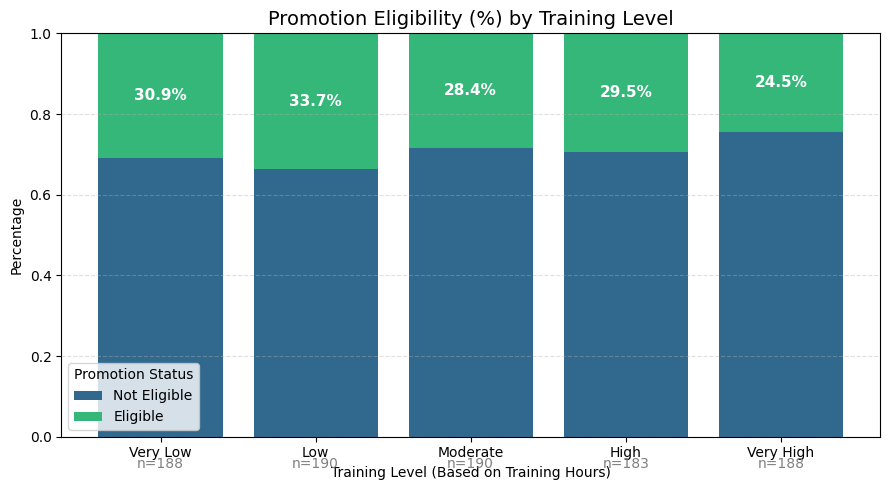

In [ ]:
# Membuat Training_Level pakai qcut (bagi per kuartil)
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['Training_Level'] = pd.qcut(df_clean['Training_Hours'],q=5,  # bagi menjadi 5 kelompok sama banyak
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])

# Menghitung proporsi promotion per kategori
prop = (df_clean.groupby('Training_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Mengubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Training_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urut: Not Eligible, Eligible

# Menghitung jumlah data per kategori
counts = df_clean['Training_Level'].value_counts().reindex(prop_pivot.index)

plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible (stacked di atasnya)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Label jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Training Level', fontsize=14)
plt.xlabel('Training Level (Based on Training Hours)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
print('Range Nilai Training_Hours')
pd.qcut(df_clean['Training_Hours'], q=5).value_counts(sort=False)

Range Nilai Training_Hours


,count
Training_Hours,
"(-0.001, 41.6]",188
"(41.6, 86.0]",190
"(86.0, 117.0]",190
"(117.0, 160.4]",183
"(160.4, 199.0]",188


## Leadership_Level

In [ ]:
df_clean['Leadership_Level'] = pd.qcut(df_clean['Leadership_Score'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
display(df_clean['Leadership_Level'].value_counts())

,count
Leadership_Level,
Medium,252
Low,235
Very High,232
High,220


In [ ]:
print('Range Nilai Leadership_Level')
pd.qcut(df_clean['Leadership_Score'], q=4).value_counts(sort=False)

Range Nilai Leadership_Level


,count
Leadership_Score,
"(-0.001, 27.5]",235
"(27.5, 50.118]",252
"(50.118, 73.0]",220
"(73.0, 99.0]",232


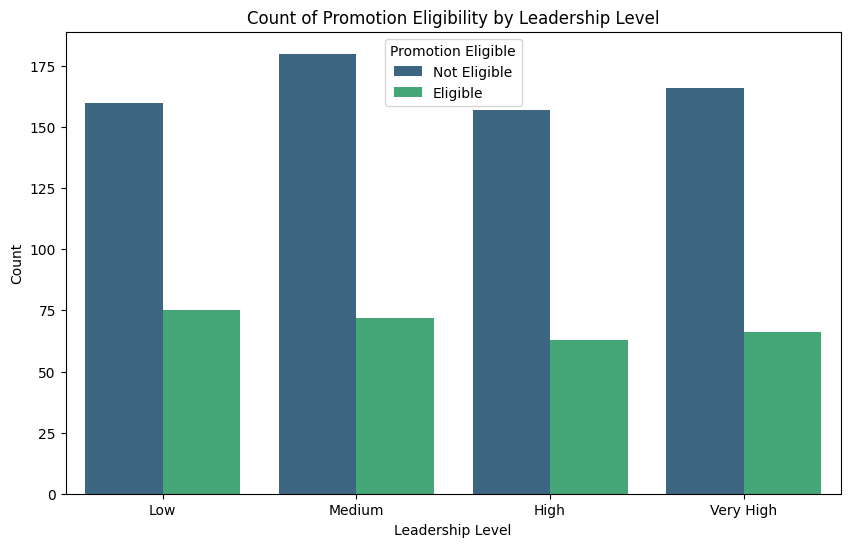

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Leadership_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Leadership Level')
plt.xlabel('Leadership Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

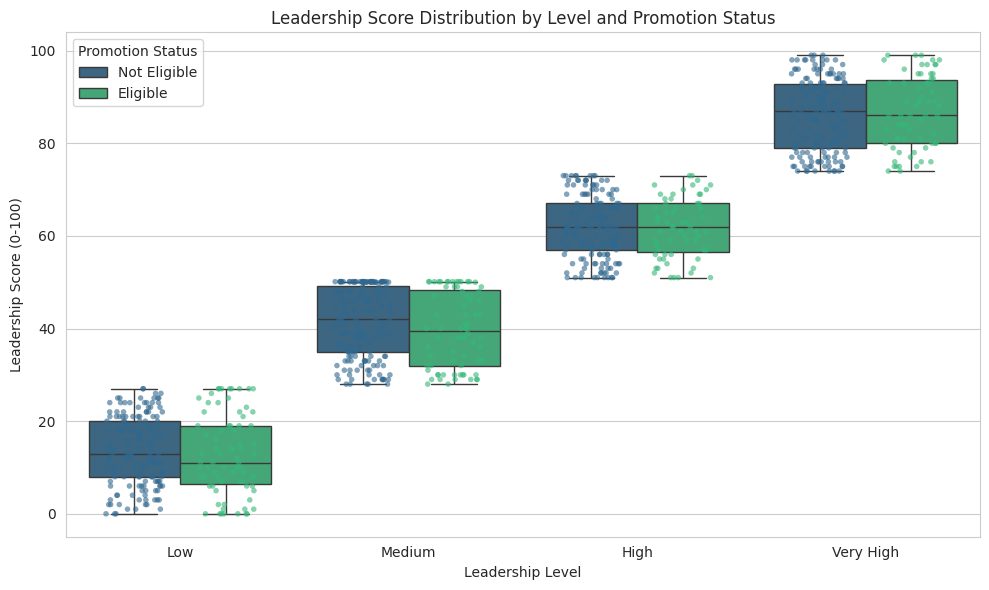

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Boxplot: menunjukkan distribusi Leadership Score per level
sns.boxplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    palette='viridis',
    showfliers=False  # hilangkan outlier biar rapi
)

# Stripplot: overlay titik individual untuk menunjukkan sebaran
sns.stripplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    dodge=True,        # pisahkan titik antar kategori hue
    jitter=0.25,       # sebar titik biar tidak tumpuk
    palette='viridis',
    alpha=0.6,
    size=4,
    linewidth=0
)

# Hapus legenda duplikat
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], ['Not Eligible', 'Eligible'], title='Promotion Status')

plt.title('Leadership Score Distribution by Level and Promotion Status')
plt.xlabel('Leadership Level')
plt.ylabel('Leadership Score (0-100)')
plt.tight_layout()
plt.show()

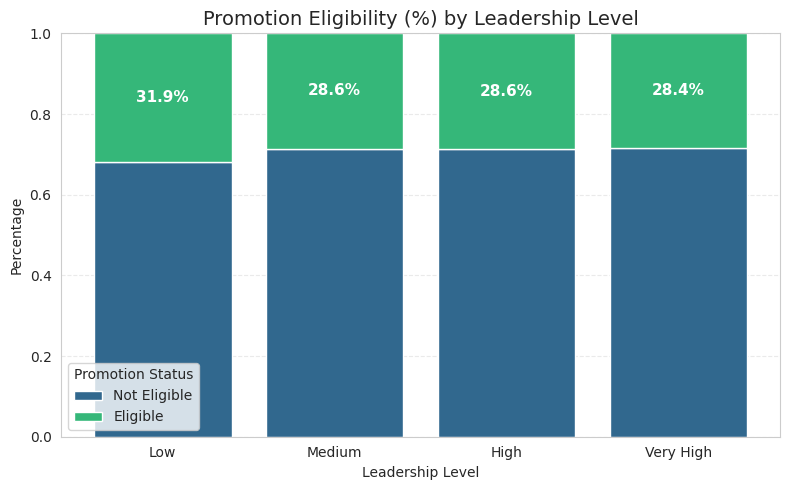

In [ ]:
#Stacked Bar Leadership Level
prop = (df_clean.groupby('Leadership_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Pivot agar jadi format wide (0/1 sebagai kolom)
prop_pivot = prop.pivot(index='Leadership_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urutan 0 dulu, lalu 1

#Plot
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar untuk Not Eligible (0)
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar untuk Eligible (1) ditumpuk di atas 0
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# % untuk Eligible
for idx, val in enumerate(prop_pivot[1]):
    total_height = prop_pivot.iloc[idx, 0] + val
    plt.text(
        idx,                        # posisi x
        prop_pivot.iloc[idx, 0] + val / 2,   # posisi y di tengah segmen eligible
        f"{val*100:.1f}%",          # label persentase
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')

plt.title('Promotion Eligibility (%) by Leadership Level', fontsize=14)
plt.xlabel('Leadership Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Project_Level


In [ ]:
df_clean['Project_per_Years'] = df_clean['Projects_Handled'] / (df_clean['Years_at_Company'] + 1)

In [ ]:
df_clean['Project_Level'] = pd.qcut(df_clean['Project_per_Years'],
                              q=4,
                              labels=['Low', 'Moderate', 'High', 'Very High'])

In [ ]:
df_clean['Project_Level'].value_counts(normalize=True)


,proportion
Project_Level,
Moderate,0.251331
Low,0.250266
High,0.250266
Very High,0.248136


In [ ]:
print('Range Nilai Project_Level')
pd.qcut(df_clean['Project_per_Years'], q=4).value_counts(sort=False)

Range Nilai Project_Level


,count
Project_per_Years,
"(-0.001, 0.359]",235
"(0.359, 0.636]",236
"(0.636, 1.154]",235
"(1.154, 19.0]",233


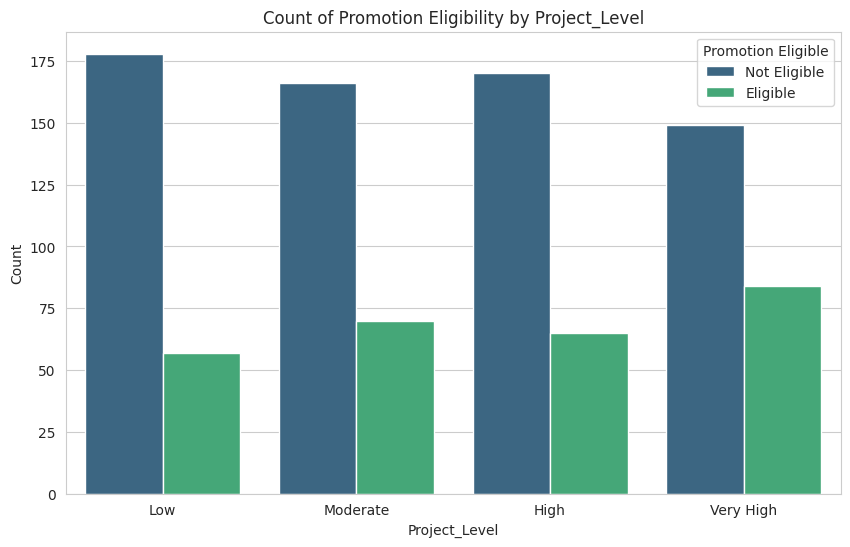

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Project_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Project_Level')
plt.xlabel('Project_Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

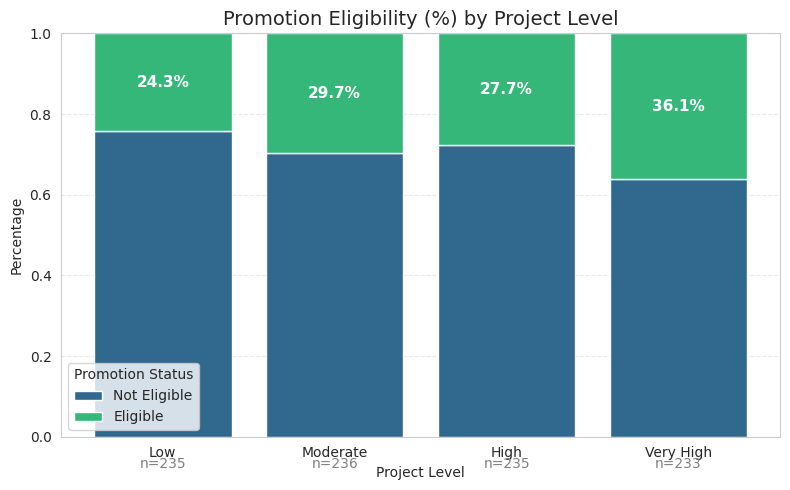

In [ ]:
#Stacked Bar

# Proporsi promotion per kategori Project_Level
prop = (
    df_clean.groupby('Project_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Pivot agar 0 dan 1 jadi kolom
prop_pivot = prop.pivot(index='Project_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutan 0 (Not Eligible), lalu 1 (Eligible)

# Hitung jumlah total per kategori (untuk label jumlah)
counts = df_clean['Project_Level'].value_counts().reindex(prop_pivot.index)

plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah segmen Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Jumlah total di bawah
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

plt.title('Promotion Eligibility (%) by Project Level', fontsize=14)
plt.xlabel('Project Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

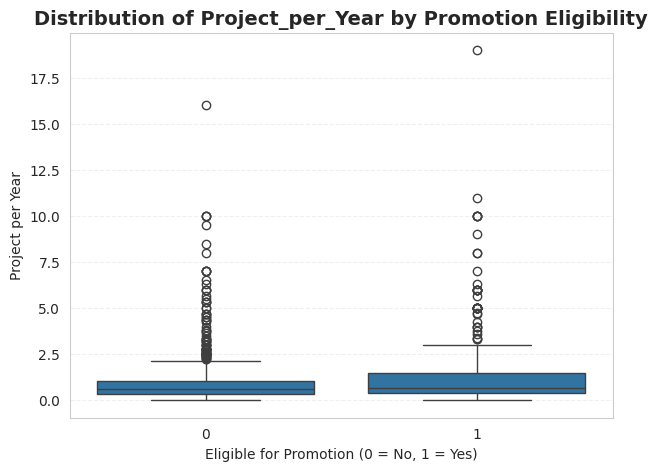

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(
    x='Promotion_Eligible',
    y='Project_per_Years',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'} # Changed keys to integers 0 and 1
)

plt.title('Distribution of Project_per_Year by Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0 = No, 1 = Yes)')
plt.ylabel('Project per Year')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Tenure Level



In [ ]:
df_clean['Tenure_Level'] = pd.qcut(df_clean['Years_at_Company'],
    q = 4,
    labels=['New', 'Mid', 'Senior', 'Veteran'])
df_clean['Tenure_Level'].value_counts()

,count
Tenure_Level,
New,256
Mid,253
Veteran,225
Senior,205


In [ ]:
print('Range Nilai Tenure_Level')
pd.qcut(df_clean['Years_at_Company'], q=4).value_counts(sort=False)

Range Nilai Tenure_Level


,count
Years_at_Company,
"(-0.001, 8.0]",256
"(8.0, 15.0]",253
"(15.0, 22.0]",205
"(22.0, 40.0]",225


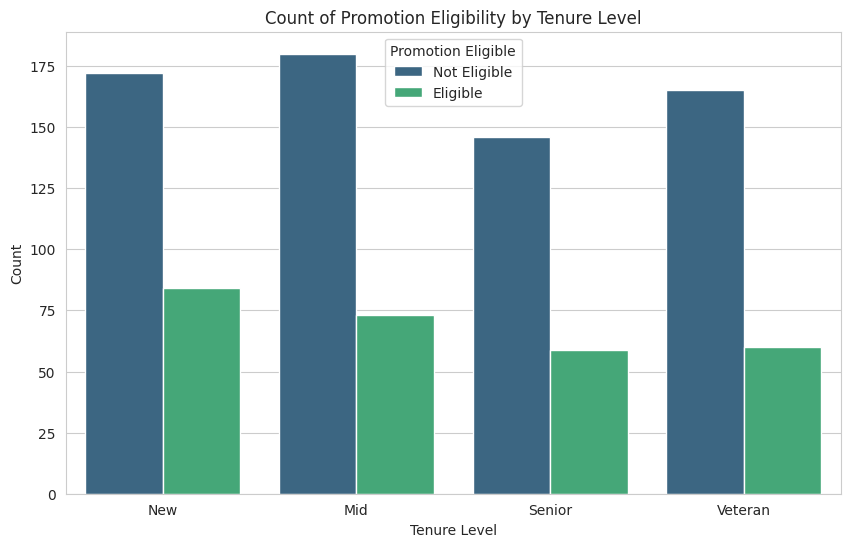

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Tenure_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Tenure Level')
plt.xlabel('Tenure Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

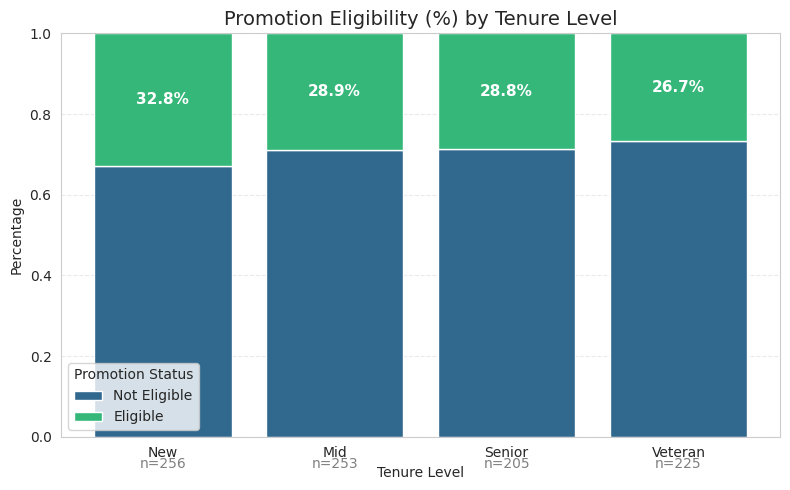

In [ ]:
#Stacked Bar
# Proporsi promotion per kategori Tenure_Level
prop = (df_clean.groupby('Tenure_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Ubah jadi pivot (biar mudah di-plot)
prop_pivot = prop.pivot(index='Tenure_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urut: Not Eligible (0), Eligible (1)

# Hitung total data per kategori (untuk label "n=")
counts = df_clean['Tenure_Level'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar bagian bawah: Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar bagian atas: Eligible (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah total (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Tenure Level', fontsize=14)
plt.xlabel('Tenure Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Age Group

In [ ]:
print('Range Age_Group')
pd.qcut(df_clean['Age'], q=4).value_counts(sort=False)

Range Age_Group


,count
Age,
"(9.999, 32.0]",247
"(32.0, 41.0]",257
"(41.0, 49.0]",206
"(49.0, 59.0]",229


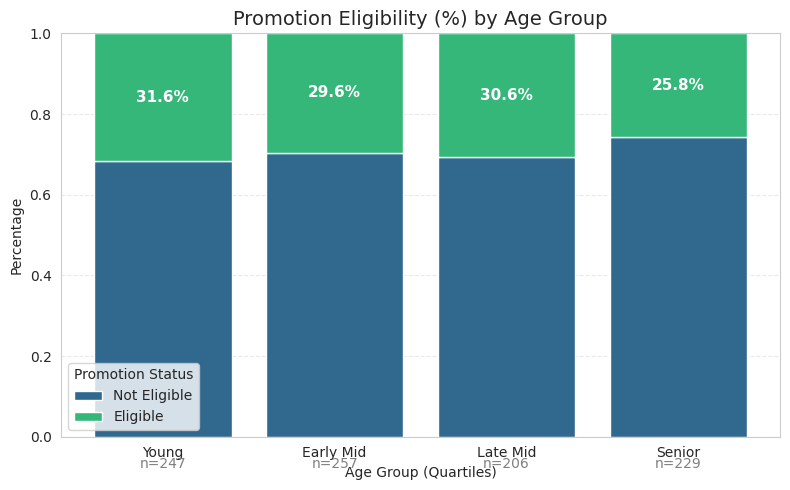

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat Age_Group dengan qcut (pembagian berdasarkan kuartil data usia)
df_clean['Age_Group'] = pd.qcut(
    df_clean['Age'],
    q=4,  # bagi menjadi 4 grup
    labels=['Young', 'Early Mid', 'Late Mid', 'Senior']
)

# Hitung proporsi promotion per kelompok usia
prop = (
    df_clean.groupby('Age_Group')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Ubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Age_Group', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutkan kolom (0=Not Eligible, 1=Eligible)

# Hitung jumlah data per kelompok usia
counts = df_clean['Age_Group'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Tampilan akhir ---
plt.title('Promotion Eligibility (%) by Age Group', fontsize=14)
plt.xlabel('Age Group (Quartiles)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Overall Performance Index

In [ ]:
df_clean.columns

Index(['Employee_ID', 'Age', 'Years_at_Company', 'Performance_Score',
       'Leadership_Score', 'Training_Hours', 'Projects_Handled',
       'Peer_Review_Score', 'Current_Position_Level', 'Promotion_Eligible',
       'Training_Level', 'Leadership_Level', 'Project_per_Years',
       'Project_Level', 'Tenure_Level', 'Age_Group'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Pastikan kolomnya ada:
cols = ['Performance_Score', 'Project_per_Years', 'Training_Hours',
        'Leadership_Score', 'Peer_Review_Score']

# Normalisasi 0–1
#scaler = MinMaxScaler()
# Apply scaler to df_clean since 'Project_per_Years' exists there
#df_clean[[col + '_norm' for col in cols]] = scaler.fit_transform(df_clean[cols])

# Buat Overall Performance Index (bobot bisa disesuaikan)
df_clean['Overall_Performance_Index'] = (
    0.20 * df_clean['Performance_Score'] +     # kinerja utama
    0.35 * df_clean['Project_per_Years'] +      # produktivitas
    0.20 * df_clean['Training_Hours'] +        # pengembangan diri
    0.10 * df_clean['Leadership_Score'] +      # kepemimpinan
    0.15 * df_clean['Peer_Review_Score']       # kerja sama
)

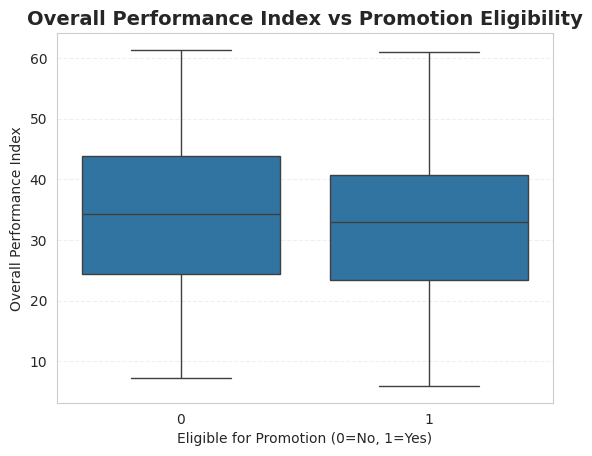

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Promotion_Eligible',
    y='Overall_Performance_Index',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'}
)
plt.title('Overall Performance Index vs Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0=No, 1=Yes)')
plt.ylabel('Overall Performance Index')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Conclusion

Feature Engineering yang dimasukkan (data categorical-ordinal):


*   Training level: karena terlihat ada sedikit perbedaan, urutan 2nd lebih besar promosinya
*   Leadership level: ada perbedaan, level leadership rendah lebih besar promosinya
*   Project level : ada perbedaan, project level tinggi lebih besar promosinya
*   Tenure level: ada perbedaan,tenure lebih rendah lebih besar promosinya
*   Age group: lebih muda, lebih besar % promosinya

In [ ]:
#drop kolom yang tidak digunakan dari data df_clean
columns_to_drop = ['Overall_Performance_Index','Employee_ID']

# Apply in pipeline
df_clean1 = df_clean.drop(columns=columns_to_drop)

In [ ]:
df_clean1.head()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible,Training_Level,Leadership_Level,Project_per_Years,Project_Level,Tenure_Level,Age_Group
0,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0,Low,Medium,0.863636,High,Senior,Young
1,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0,Low,Medium,1.222222,Very High,New,Senior
2,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0,Moderate,Low,0.600000,Moderate,Mid,Senior
3,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0,Very Low,High,0.240000,Low,Veteran,Early Mid
4,41.0,15.0,4.0,64.0,57.0,16.0,59.0,Junior,0,Low,High,1.000000,High,Mid,Early Mid


In [ ]:
df_clean1.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930,1.203685
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803,1.789169
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000,0.358571
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000,0.636364
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000,1.153846
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000,19.000000


# Feature Transformation

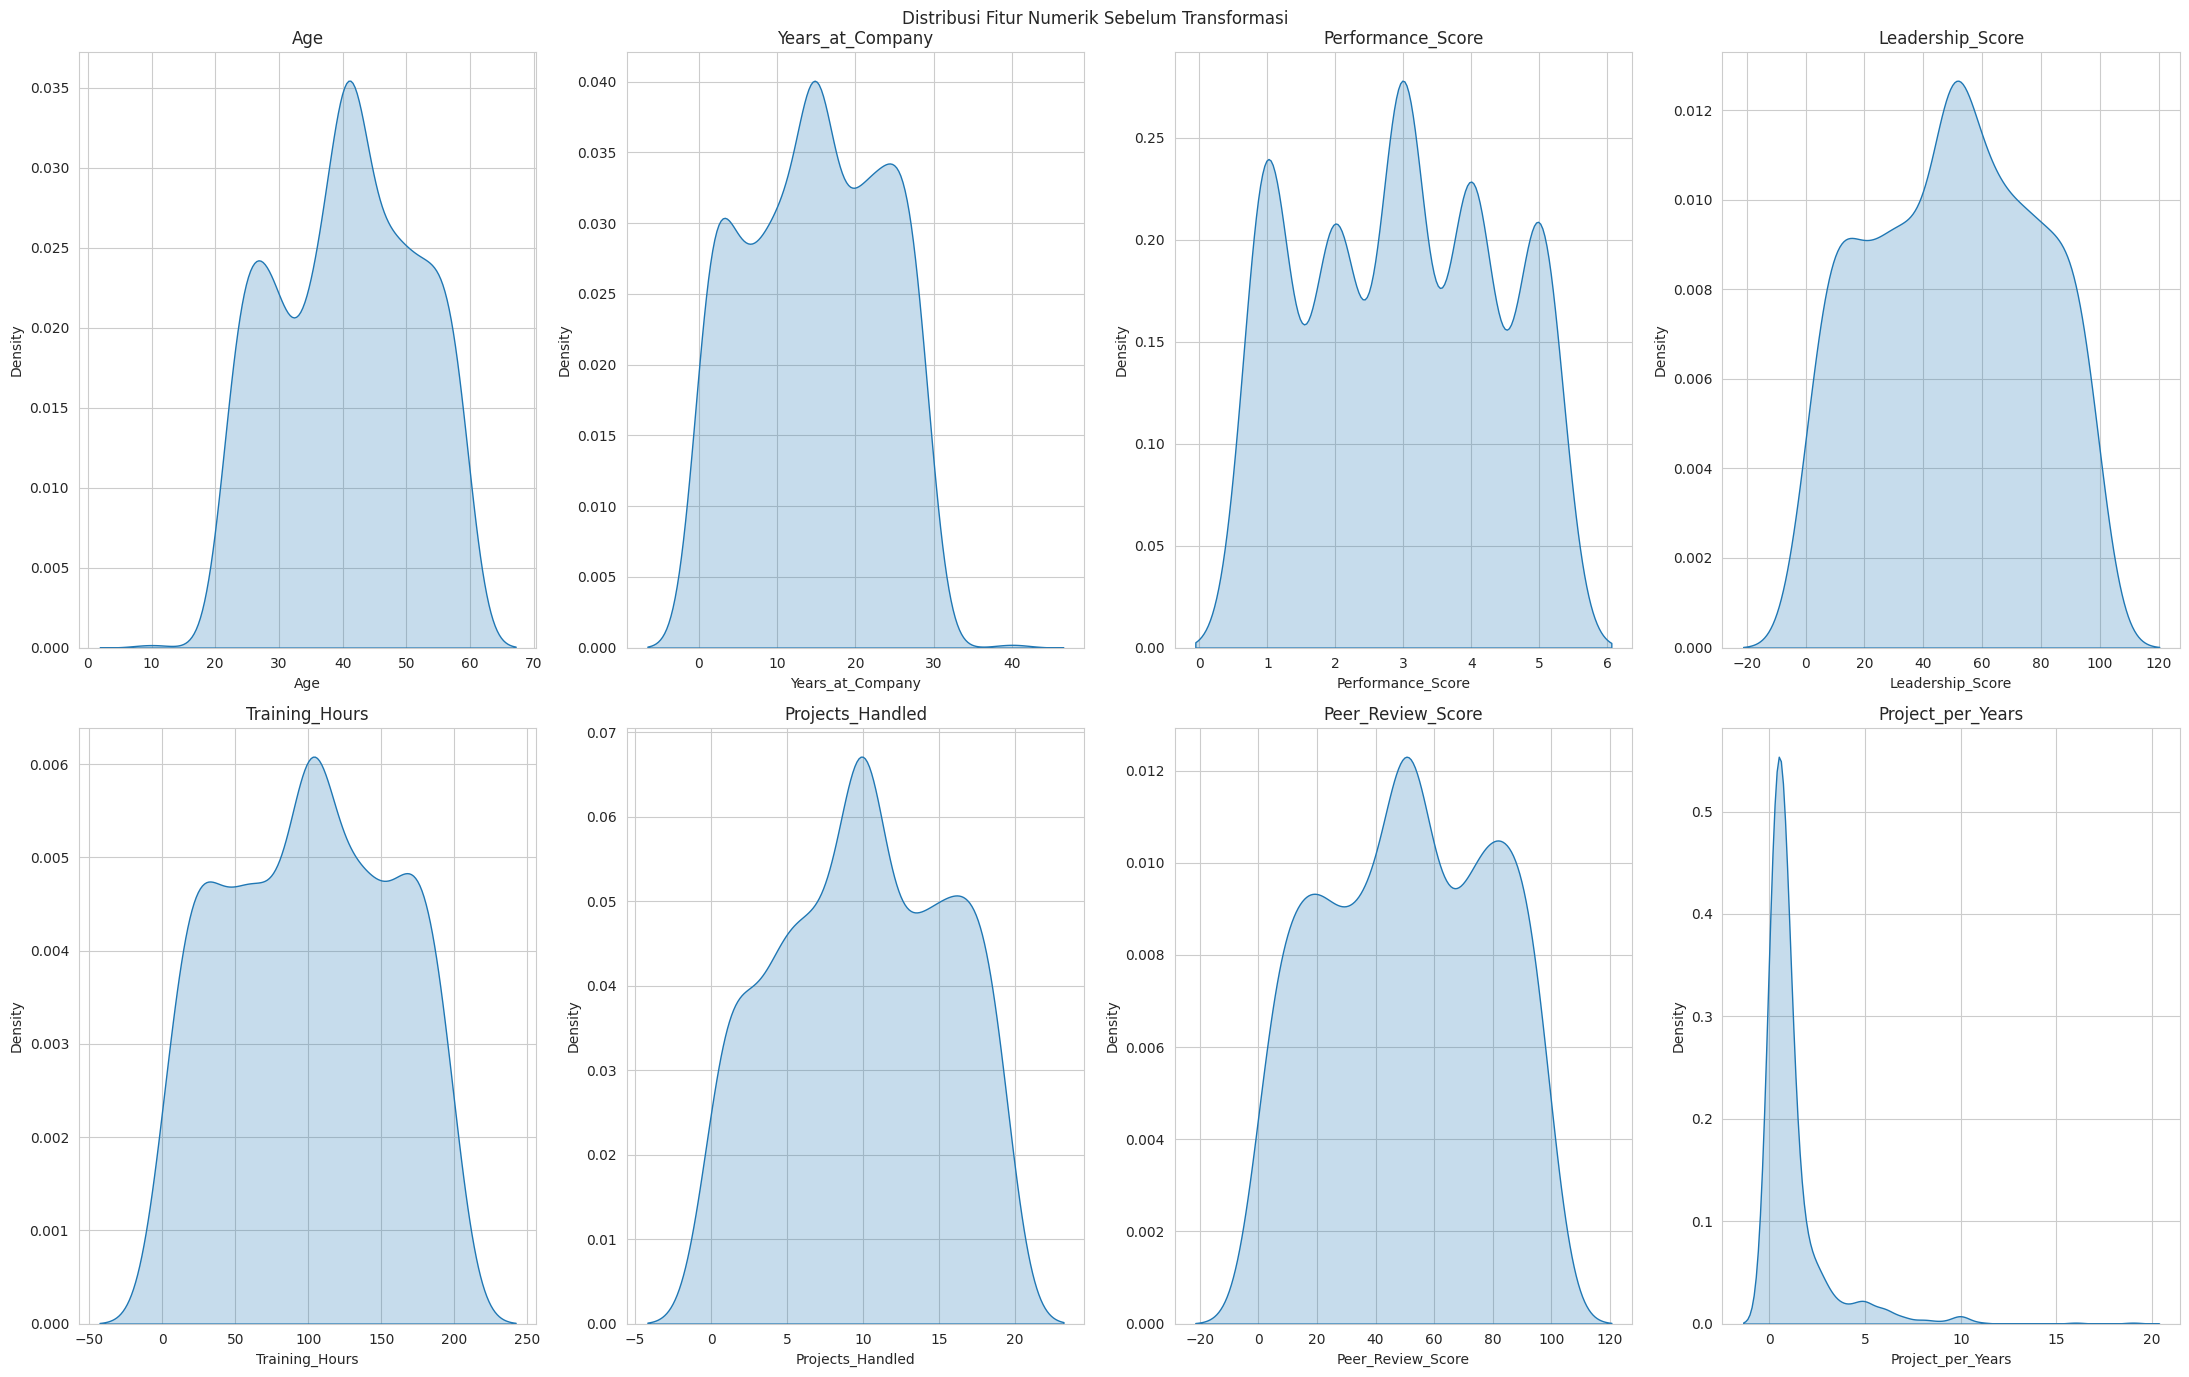

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi tipe fitur
num_features = ['Age', 'Years_at_Company', 'Performance_Score','Leadership_Score', 'Training_Hours',
    'Projects_Handled', 'Peer_Review_Score', 'Project_per_Years']
fig, axes = plt.subplots(2, 4, figsize=(22, 14))
axes=axes.flatten()
for i, col in enumerate (num_features):
    sns.kdeplot(data=df_clean1, x=col, fill=True, ax=axes[i])
    axes[i].set_title (col)

#mhapus kolom yang tidak diperlukan
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik Sebelum Transformasi')


plt.tight_layout()
plt.show()

## Log Transformation


Dua opsi, 1 dilakukan log transformation dan 1 lagi tanpa log transformation

log transformasi untuk Age, Projecy_per_Years, dan Years_at_Company

In [ ]:
#dengan log transformation dari df_clean1
import numpy as np
import pandas as pd
df_logtrans = df_clean1.copy()

cols_to_log = ['Age', 'Years_at_Company', 'Project_per_Years']
cols_to_log = [c for c in cols_to_log if c in df_logtrans.columns]

df_logtrans[cols_to_log] = np.log1p(df_logtrans[cols_to_log])

## One Hot Encoding

In [ ]:
cat_features = [
    'Current_Position_Level',
    'Training_Level',
    'Leadership_Level',
    'Project_Level',
    'Tenure_Level',
    'Age_Group']

### OHE dengan log transform

In [ ]:
#dengan log transfrom
df_encod = pd.get_dummies(df_logtrans,
                            columns=cat_features,
                            drop_first=True)  # drop_first
print(df_encod.shape)
df_encod.head()

(939, 28)


,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Current_Position_Level_Lead,...,Leadership_Level_Very High,Project_Level_Moderate,Project_Level_High,Project_Level_Very High,Tenure_Level_Mid,Tenure_Level_Senior,Tenure_Level_Veteran,Age_Group_Early Mid,Age_Group_Late Mid,Age_Group_Senior
0,3.218876,3.091042,2.0,44.0,42.0,19.0,61.0,0,0.622530,False,...,False,False,True,False,False,True,False,False,False,False
1,3.931826,2.197225,5.0,45.0,66.0,11.0,6.0,0,0.798508,False,...,False,False,False,True,False,False,False,False,False,True
2,4.043051,2.302585,5.0,19.0,96.0,6.0,86.0,0,0.470004,True,...,False,True,False,False,True,False,False,False,False,True
3,3.688879,3.218876,4.0,51.0,16.0,6.0,52.0,0,0.215111,False,...,False,False,False,False,False,False,True,True,False,False
4,3.737670,2.772589,4.0,64.0,57.0,16.0,59.0,0,0.693147,False,...,False,False,True,False,True,False,False,True,False,False


### OHE tanpa log transform

In [ ]:
#tanpa log transfrom
df_encod1 = pd.get_dummies(df_clean1,
                            columns=cat_features,
                            drop_first=True)  # drop_first
print(df_encod1.shape)
df_encod1.head()

(939, 28)


,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Current_Position_Level_Lead,...,Leadership_Level_Very High,Project_Level_Moderate,Project_Level_High,Project_Level_Very High,Tenure_Level_Mid,Tenure_Level_Senior,Tenure_Level_Veteran,Age_Group_Early Mid,Age_Group_Late Mid,Age_Group_Senior
0,24.0,21.0,2.0,44.0,42.0,19.0,61.0,0,0.863636,False,...,False,False,True,False,False,True,False,False,False,False
1,50.0,8.0,5.0,45.0,66.0,11.0,6.0,0,1.222222,False,...,False,False,False,True,False,False,False,False,False,True
2,56.0,9.0,5.0,19.0,96.0,6.0,86.0,0,0.600000,True,...,False,True,False,False,True,False,False,False,False,True
3,39.0,24.0,4.0,51.0,16.0,6.0,52.0,0,0.240000,False,...,False,False,False,False,False,False,True,True,False,False
4,41.0,15.0,4.0,64.0,57.0,16.0,59.0,0,1.000000,False,...,False,False,True,False,True,False,False,True,False,False


## Imbalance Handling

### Split data

In [ ]:
from sklearn.model_selection import train_test_split

#### Dengan Log transfrom

In [ ]:
# Dataset dengan log transform
X = df_encod.drop(['Promotion_Eligible'], axis=1)
y = df_encod['Promotion_Eligible']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Tanpa Log Transfrom

In [ ]:
from sklearn.model_selection import train_test_split

X_1 = df_encod1.drop(['Promotion_Eligible'], axis=1)
y_1= df_encod1['Promotion_Eligible']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1,test_size=0.2,stratify=y,random_state=42)

### Imbalance Check

#### Dengan Log Transform

In [ ]:
# dengan log transfrom
print('Distribusi kelas sebelum balancing:')
print(y_train.value_counts())
print('\nProporsi kelas:')
print(y_train.value_counts(normalize=True))

Distribusi kelas sebelum balancing:
Promotion_Eligible
0    530
1    221
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
0    0.705726
1    0.294274
Name: proportion, dtype: float64


#### Tanpa log transform

In [ ]:
#Tanpa log transform
print('Distribusi kelas sebelum balancing:')
print(y_train_1.value_counts())
print('\nProporsi kelas:')
print(y_train_1.value_counts(normalize=True))

Distribusi kelas sebelum balancing:
Promotion_Eligible
0    530
1    221
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
0    0.705726
1    0.294274
Name: proportion, dtype: float64


### SMOTE

#### Dengan log transfrom

In [ ]:
#dengan log transform
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Setelah SMOTE:')
print(y_train_bal.value_counts())
print('\nProporsi kelas:')
print(y_train_bal.value_counts(normalize=True))

Setelah SMOTE:
Promotion_Eligible
1    530
0    530
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
1    0.5
0    0.5
Name: proportion, dtype: float64


#### Tanpa log transform

In [ ]:
#tanpa log transform
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal1, y_train_bal1 = smote.fit_resample(X_train_1, y_train_1)

print('Setelah SMOTE:')
print(y_train_bal1.value_counts())
print('\nProporsi kelas:')
print(y_train_bal1.value_counts(normalize=True))

Setelah SMOTE:
Promotion_Eligible
1    530
0    530
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
1    0.5
0    0.5
Name: proportion, dtype: float64


## Standardisasi

### Dengan log transform

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

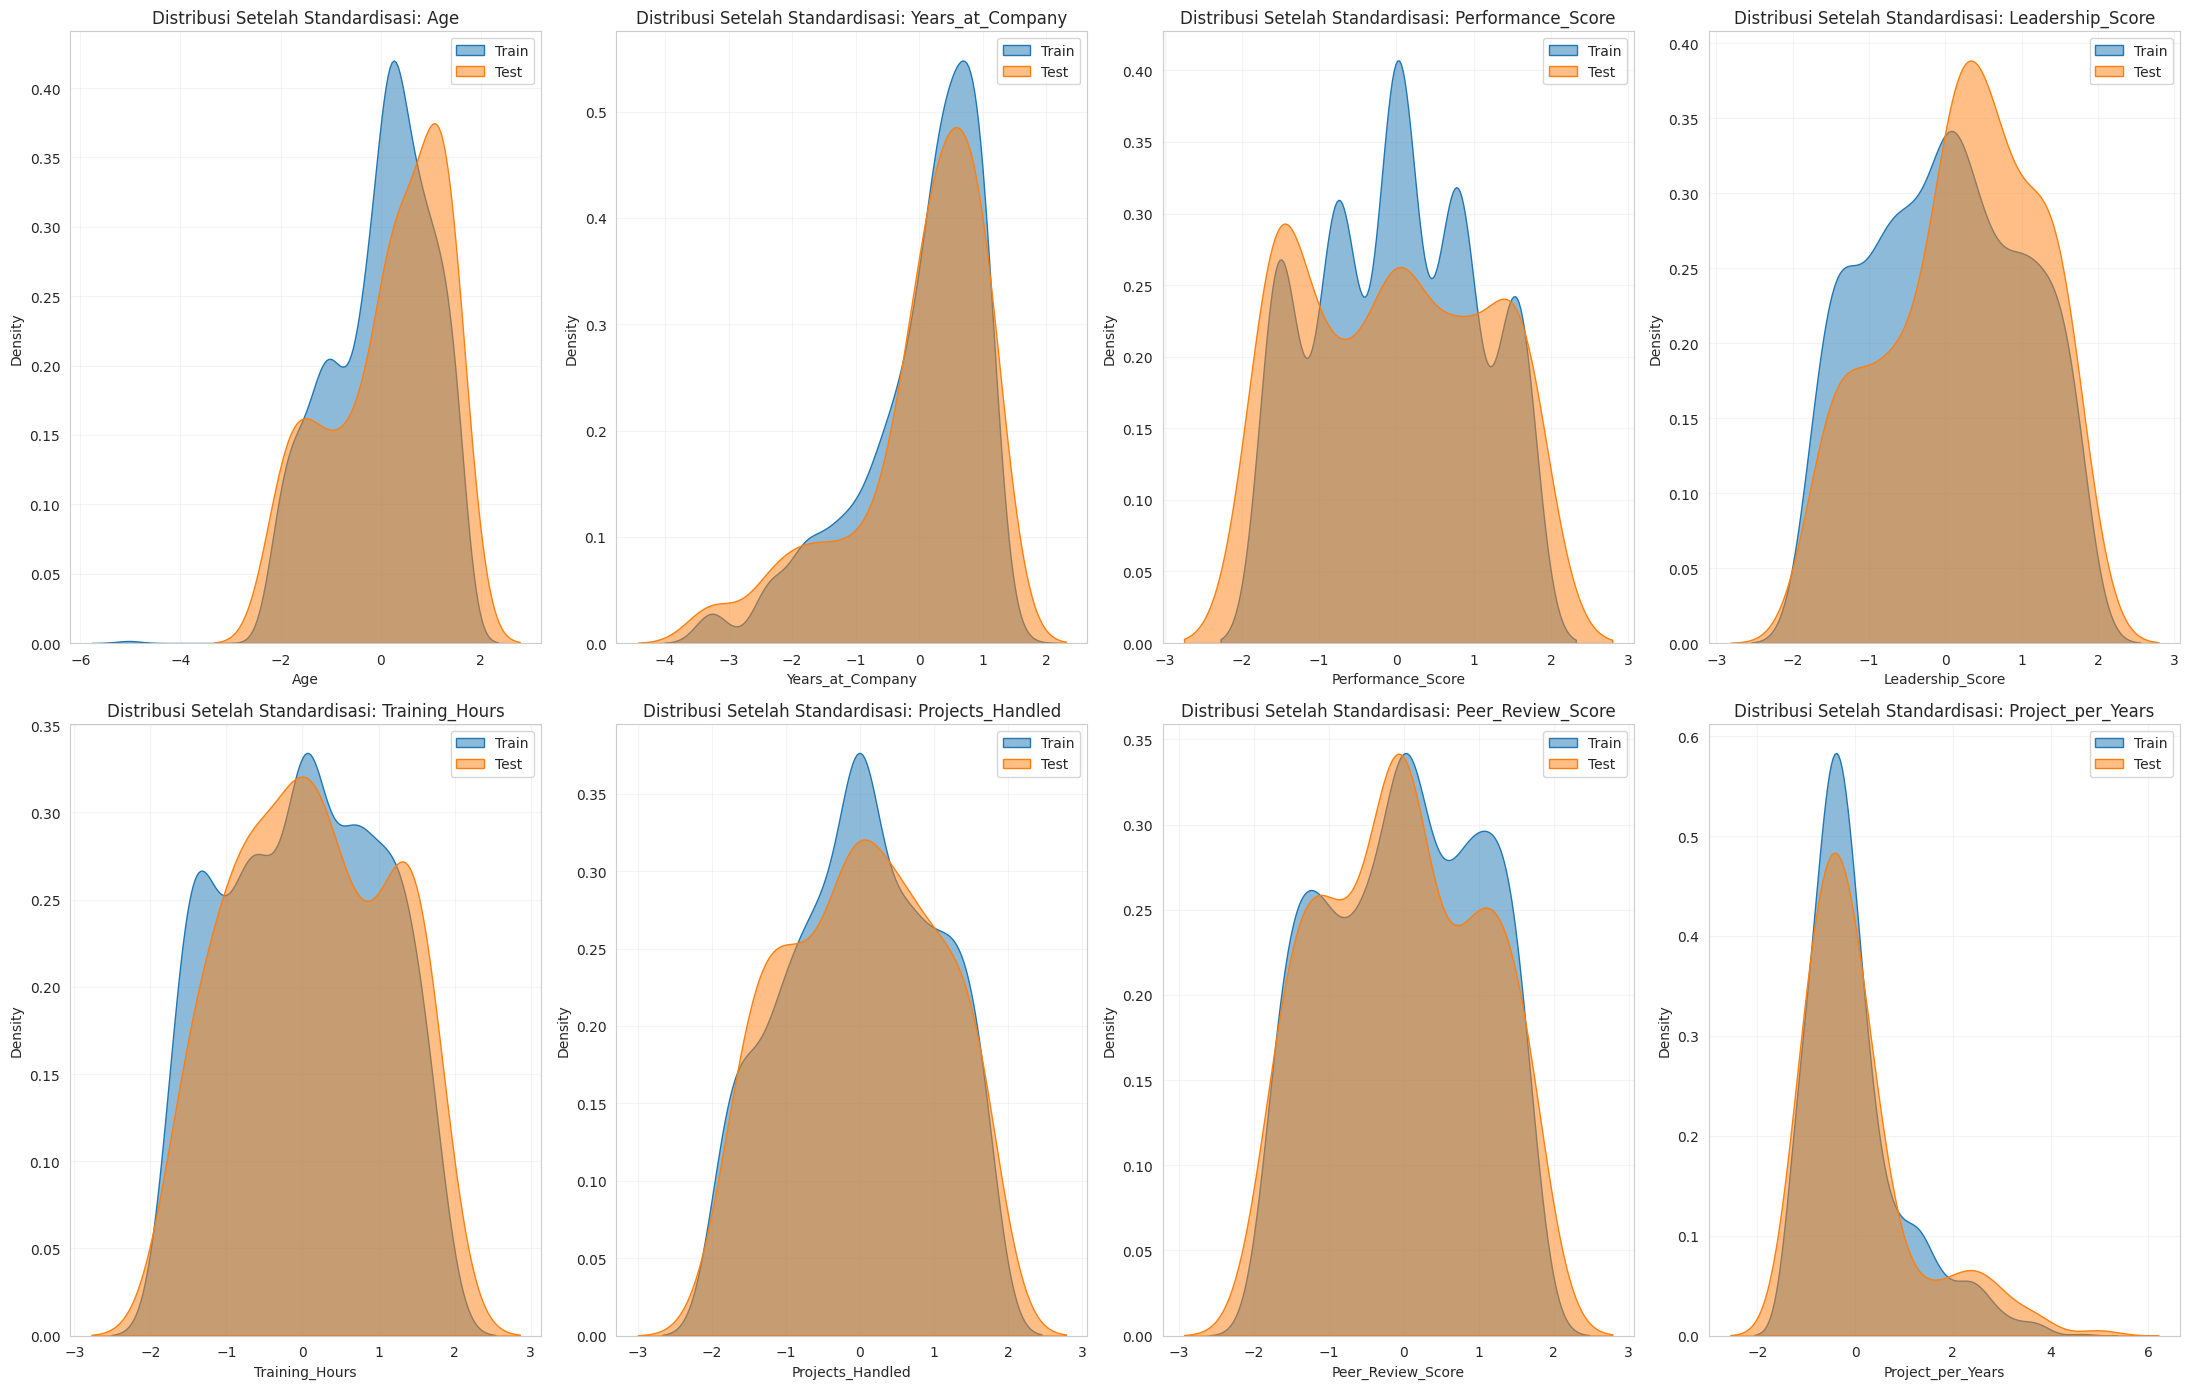

In [ ]:
# Grafik hasil log transform dan standardisasi
#Convert scaled data back to DataFrame dengan nama kolom
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_bal.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Plot distribusi training set setelah standardisasi
plt.figure(figsize=(22, 14))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 4, i)
    sns.kdeplot(X_train_scaled_df[col], fill=True, alpha=0.5, label='Train')
    sns.kdeplot(X_test_scaled_df[col], fill=True, alpha=0.5, label='Test')
    plt.title(f'Distribusi Setelah Standardisasi: {col}')
    plt.legend()
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Tanpa log transform

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train_bal1)
X_test_scaled1 = scaler.transform(X_test_1)

# Modelling

In [ ]:
# Model & Evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

#### Evaluations Metrics

## Dengan Log Transform

In [ ]:
X_train_scaled.shape, X_test_scaled.shape, y_train_bal.shape, y_test.shape

((1060, 27), (188, 27), (1060,), (188,))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    fbeta_score, average_precision_score
)
from sklearn.model_selection import cross_validate

def evaluate_model_summary(model, X_train, X_test, y_train, y_test, model_name=""):
    """
    Evaluasi model klasifikasi (train, test, dan cross-validation)
    dengan tambahan PR-AUC (Precision-Recall AUC)
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics_dict = {
        'Model': model_name,
        'Accuracy_Train': accuracy_score(y_train, y_pred_train),
        'Accuracy_Test': accuracy_score(y_test, y_pred_test),
        'Precision_Train': precision_score(y_train, y_pred_train, zero_division=0),
        'Precision_Test': precision_score(y_test, y_pred_test, zero_division=0),
        'Recall_Train': recall_score(y_train, y_pred_train, zero_division=0),
        'Recall_Test': recall_score(y_test, y_pred_test, zero_division=0),
        'F1_Train': f1_score(y_train, y_pred_train, zero_division=0),
        'F1_Test': f1_score(y_test, y_pred_test, zero_division=0),
        'F2_Train': fbeta_score(y_train, y_pred_train, beta=2, zero_division=0),
        'F2_Test': fbeta_score(y_test, y_pred_test, beta=2, zero_division=0),
        'ROC_AUC_Train': roc_auc_score(y_train, y_proba_train),
        'ROC_AUC_Test': roc_auc_score(y_test, y_proba_test),
        'PR_AUC_Train': average_precision_score(y_train, y_proba_train),
        'PR_AUC_Test': average_precision_score(y_test, y_proba_test)
    }

    # Cross Validation Scores (tambahkan PR-AUC juga)
    cv_scores = cross_validate(
        model, X_train, y_train, cv=5,
        scoring={
            'recall': 'recall',
            'roc_auc': 'roc_auc',
            'pr_auc': 'average_precision'
        },
        return_train_score=True
    )

    metrics_dict.update({
        'CV_Recall_Train': cv_scores['train_recall'].mean(),
        'CV_Recall_Test': cv_scores['test_recall'].mean(),
        'CV_ROC_AUC_Train': cv_scores['train_roc_auc'].mean(),
        'CV_ROC_AUC_Test': cv_scores['test_roc_auc'].mean(),
        'CV_PR_AUC_Train': cv_scores['train_pr_auc'].mean(),
        'CV_PR_AUC_Test': cv_scores['test_pr_auc'].mean()
    })

    return pd.DataFrame([metrics_dict])


def print_model_results(results_df):
    """Print hasil evaluasi model dalam format tabel rapi"""
    print(f"\n{'='*80}")
    print(f"MODEL EVALUATION RESULTS")
    print(f"{'='*80}")
    display(results_df.round(3).T)


#### Logistic Regression

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

print("MODEL 1: LOGISTIC REGRESSION")

# 1. BASELINE MODEL
lr_baseline = LogisticRegression(random_state=42)
lr_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
lr_base_results = evaluate_model_summary(lr_baseline, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LogReg Baseline")
print_model_results(lr_base_results)

MODEL 1: LOGISTIC REGRESSION

MODEL EVALUATION RESULTS


,0
Model,LogReg Baseline
Accuracy_Train,0.766
Accuracy_Test,0.681
Precision_Train,0.863
Precision_Test,0.419
Recall_Train,0.632
Recall_Test,0.236
F1_Train,0.73
F1_Test,0.302
F2_Train,0.668


In [ ]:
# 2. TUNING 2 MODEL
print("\nTuning 2 Logistic Regression...")
param_dist = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-4, 2, 100),
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']}

lr = LogisticRegression(max_iter=1000, random_state=42)
rs_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

rs_lr.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_lr.best_params_}")
print(f" Best CV ROC-AUC: {rs_lr.best_score_:.3f}")

# BEST TUNED MODEL
lr_best = rs_lr.best_estimator_

# EVALUATION TUNED MODEL
lr_tuned_results = evaluate_model_summary(
    lr_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LogReg Tuned 2")
lr_display = print_model_results(lr_tuned_results)


Tuning 2 Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': np.float64(57.223676593502205)}
 Best CV ROC-AUC: 0.787

MODEL EVALUATION RESULTS


,0
Model,LogReg Tuned 2
Accuracy_Train,0.76
Accuracy_Test,0.676
Precision_Train,0.847
Precision_Test,0.406
Recall_Train,0.636
Recall_Test,0.236
F1_Train,0.726
F1_Test,0.299
F2_Train,0.669


Tuning 2 mengubah paramater C (lebih besar) dengan cross validation, menghasilkan model yang relatif stabil, tetapi recall dan AUC test masih rendah

Model Logistic Regression belum efektif untuk memprediksi promosi karyawan secara akurat, terutama dalam mengenali talenta potensial (recall rendah).

Artinya, masih banyak karyawan yang layak promosi tidak terdeteksi model.

### XGBoost

In [ ]:
#1.Base XGBoost
from xgboost import XGBClassifier

print("MODEL 2: XGBoost")

# 1. BASELINE MODEL
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
xgb_base_results = evaluate_model_summary(xgb_baseline, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Baseline")
print_model_results(xgb_base_results)

MODEL 2: XGBoost

MODEL EVALUATION RESULTS


,0
Model,XGB Baseline
Accuracy_Train,1.0
Accuracy_Test,0.633
Precision_Train,1.0
Precision_Test,0.348
Recall_Train,1.0
Recall_Test,0.291
F1_Train,1.0
F1_Test,0.317
F2_Train,1.0


In [ ]:
#2. Tuning XGBoost 3
print("==================================================")
print("Tuning XGBoost (Range Moderat Terbatas)")
print("==================================================")

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter range lebih sempit untuk stabilitas
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': np.logspace(-2, 2, 10)}


xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    n_jobs=-1)

# RandomizedSearchCV
rs_xgb_mod = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

# Fit model
rs_xgb_mod.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_xgb_mod.best_params_}")
print(f"Best CV ROC-AUC: {rs_xgb_mod.best_score_:.3f}")

# Model terbaik
xgb_best = rs_xgb_mod.best_estimator_

#Evaluasi
xgb_tuned_results = evaluate_model_summary(
    xgb_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Tuned (Moderate Range Limited)")
print_model_results(xgb_tuned_results)

Tuning XGBoost (Range Moderat Terbatas)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'reg_lambda': np.float64(12.915496650148826), 'n_estimators': 100, 'max_depth': 5, 'learning_rate': np.float64(0.15), 'gamma': 0, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.825

MODEL EVALUATION RESULTS


,0
Model,XGB Tuned (Moderate Range Limited)
Accuracy_Train,0.964
Accuracy_Test,0.633
Precision_Train,0.994
Precision_Test,0.294
Recall_Train,0.934
Recall_Test,0.182
F1_Train,0.963
F1_Test,0.225
F2_Train,0.945


### Decision Tree

In [ ]:
# 1. BASELINE MODEL
from sklearn.tree import DecisionTreeClassifier

print("MODEL 3: DECISION TREE CLASSIFIER")

# Baseline Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_scaled, y_train_bal)  # gunakan y_train jika tidak SMOTE

# Evaluate baseline
dt_base_results = evaluate_model_summary(
    dt_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "DecisionTree Baseline"
)
print_model_results(dt_base_results)

MODEL 3: DECISION TREE CLASSIFIER

MODEL EVALUATION RESULTS


,0
Model,DecisionTree Baseline
Accuracy_Train,1.0
Accuracy_Test,0.585
Precision_Train,1.0
Precision_Test,0.317
Recall_Train,1.0
Recall_Test,0.364
F1_Train,1.0
F1_Test,0.339
F2_Train,1.0


In [ ]:
# 2. TUNING MODEL
from sklearn.model_selection import RandomizedSearchCV

print("\nTuning Decision Tree (Moderate Range)...")

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,4,5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [ 1,2, 4, 6, 8],
    'class_weight': [None, 'balanced']
}

dt = DecisionTreeClassifier(random_state=42)

rs_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rs_dt.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_dt.best_params_}")
print(f" Best CV ROC-AUC: {rs_dt.best_score_:.3f}")

# Best tuned model
dt_best = rs_dt.best_estimator_

# Evaluate tuned model
dt_tuned_results = evaluate_model_summary(
    dt_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "DecisionTree Tuned"
)
dt_display = print_model_results(dt_tuned_results)


Tuning Decision Tree (Moderate Range)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'gini', 'class_weight': 'balanced'}
 Best CV ROC-AUC: 0.658

MODEL EVALUATION RESULTS


,0
Model,DecisionTree Tuned
Accuracy_Train,0.675
Accuracy_Test,0.559
Precision_Train,0.677
Precision_Test,0.311
Recall_Train,0.67
Recall_Test,0.418
F1_Train,0.674
F1_Test,0.357
F2_Train,0.671


### Random Forest

In [ ]:
# MODEL 4: RANDOM FOREST CLASSIFIER (BASELINE)
# ==================================================
from sklearn.ensemble import RandomForestClassifier

print("MODEL 4: Random Forest Classifier")

# 1. BASELINE MODEL
rf_baseline = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    criterion='gini',
    class_weight='balanced',
    n_jobs=-1)

# Fit model
rf_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
rf_base_results = evaluate_model_summary(
    rf_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "RandomForest Baseline")

# Print results
print_model_results(rf_base_results)

MODEL 4: Random Forest Classifier

MODEL EVALUATION RESULTS


,0
Model,RandomForest Baseline
Accuracy_Train,1.0
Accuracy_Test,0.681
Precision_Train,1.0
Precision_Test,0.4
Recall_Train,1.0
Recall_Test,0.182
F1_Train,1.0
F1_Test,0.25
F2_Train,1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

print("\nTuning Random Forest (Moderate Range - RandomSearch)...")

# Parameter distributions
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None],
    'criterion': ['gini', 'entropy']
}

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized Search setup
rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    scoring='roc_auc',          # fokus pada ROC-AUC
    cv=5,
    n_iter=20,                  # jumlah kombinasi (bisa ditambah kalau ingin lebih optimal)
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit tuning pada data training hasil SMOTE
rs_rf.fit(X_train_bal, y_train_bal)

print(f"Best parameters: {rs_rf.best_params_}")
print(f"Best CV ROC-AUC: {rs_rf.best_score_:.3f}")

# Simpan best model
rf_best = rs_rf.best_estimator_

# Evaluasi model hasil tuning
rf_tuned_results = evaluate_model_summary(
    rf_best,
    X_train_bal, X_test,        # train pakai SMOTE, test pakai data asli
    y_train_bal, y_test,
    "RandomForest Tuned (RandomSearch)"
)

# Tampilkan hasil
print_model_results(rf_tuned_results)



Tuning Random Forest (Moderate Range - RandomSearch)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 300, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False}
Best CV ROC-AUC: 0.830

MODEL EVALUATION RESULTS


,0
Model,RandomForest Tuned (RandomSearch)
Accuracy_Train,0.948
Accuracy_Test,0.707
Precision_Train,0.992
Precision_Test,0.5
Recall_Train,0.904
Recall_Test,0.164
F1_Train,0.946
F1_Test,0.247
F2_Train,0.92


### Adaboost

In [ ]:
# MODEL 5: ADABOOST CLASSIFIER (BASELINE)
# ==================================================
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

print("MODEL 5: AdaBoost Classifier")

# 1. BASELINE MODEL

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base = DecisionTreeClassifier(max_depth=1)
adb_baseline = AdaBoostClassifier(random_state=42
)

# Fit model
adb_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
adb_base_results = evaluate_model_summary(
    adb_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "AdaBoost Baseline"
)

# Print results
print_model_results(adb_base_results)

MODEL 5: AdaBoost Classifier

MODEL EVALUATION RESULTS


,0
Model,AdaBoost Baseline
Accuracy_Train,0.748
Accuracy_Test,0.649
Precision_Train,0.778
Precision_Test,0.333
Recall_Train,0.694
Recall_Test,0.2
F1_Train,0.734
F1_Test,0.25
F2_Train,0.71


In [ ]:
# 2. TUNING MODEL (Moderate Range-Limited)
print("\nTuning AdaBoost (Moderate Range Limited)...")

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.3, 0.4, 0.5, 0.6, 0.7],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=42),
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42),
        DecisionTreeClassifier(max_depth=4, random_state=42)
    ]}


rs_adb = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',  # fokus ke recall untuk test yang rendah
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

rs_adb.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_adb.best_params_}")
print(f"Best CV Recall: {rs_adb.best_score_:.3f}")

# Best tuned model
adb_best = rs_adb.best_estimator_

# Evaluate tuned model
adb_tuned_results = evaluate_model_summary(
    adb_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "AdaBoost Tuned")
print_model_results(adb_tuned_results)


Tuning AdaBoost (Moderate Range Limited)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'n_estimators': 200, 'learning_rate': 0.4, 'estimator': DecisionTreeClassifier(max_depth=4, random_state=42)}
Best CV Recall: 0.666

MODEL EVALUATION RESULTS


,0
Model,AdaBoost Tuned
Accuracy_Train,0.973
Accuracy_Test,0.633
Precision_Train,0.992
Precision_Test,0.316
Recall_Train,0.953
Recall_Test,0.218
F1_Train,0.972
F1_Test,0.258
F2_Train,0.96


### SVC -Support Vector Classif

In [ ]:
# MODEL 6: SVC -Support Vector Classification
# ==================================================
from sklearn.svm import SVC

print("MODEL 6: Support Vector Classifier (SVC)")

# 1. BASELINE MODEL
svc_baseline = SVC(
    kernel='rbf',          # RBF = default kernel, bagus untuk non-linear data
    C=1.0,                 # Regularization strength
    gamma='scale',         # Auto gamma (1 / (n_features * X.var()))
    class_weight='balanced',  # Menangani class imbalance
    probability=True,      # Untuk ROC AUC
    random_state=42
)

# Fit model
svc_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate baseline
svc_base_results = evaluate_model_summary(
    svc_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "SVC Baseline"
)

# Print results
print_model_results(svc_base_results)

MODEL 6: Support Vector Classifier (SVC)

MODEL EVALUATION RESULTS


,0
Model,SVC Baseline
Accuracy_Train,0.863
Accuracy_Test,0.676
Precision_Train,0.966
Precision_Test,0.364
Recall_Train,0.753
Recall_Test,0.145
F1_Train,0.846
F1_Test,0.208
F2_Train,0.788


In [ ]:
# 2. TUNING MODEL (Moderate Range)
# ==================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

print("\nTuning SVC (Moderate Range)...")

# Parameter grid (moderat)
param_dist = {
    'C': [0.1, 0.5, 1, 10],
    'kernel': ['rbf'], #linear
    'gamma': ['scale'], #scale
    'class_weight': [None, 'balanced']
}

# Base model
svc = SVC(probability=True, random_state=42)

# Randomized search setup
rs_svc = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',   # fokus utama recall dulu, tapi nanti lihat trade-off accuracy
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit search
rs_svc.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_svc.best_params_}")
print(f"Best CV Recall: {rs_svc.best_score_:.3f}")

# Best tuned model
svc_best = rs_svc.best_estimator_

# Evaluate tuned model
svc_tuned_results = evaluate_model_summary(
    svc_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "SVC Tuned"
)

# Display results
print_model_results(svc_tuned_results)


Tuning SVC (Moderate Range)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'class_weight': None, 'C': 10}
Best CV Recall: 0.698

MODEL EVALUATION RESULTS


,0
Model,SVC Tuned
Accuracy_Train,0.984
Accuracy_Test,0.59
Precision_Train,0.99
Precision_Test,0.304
Recall_Train,0.977
Recall_Test,0.309
F1_Train,0.984
F1_Test,0.306
F2_Train,0.98


### KNN

In [ ]:

# KNN Base
from sklearn.neighbors import KNeighborsClassifier

# Base model sederhana
knn_base = KNeighborsClassifier(n_neighbors=5)  # default basic setting


knn_base.fit(X_train_scaled, y_train_bal)

knn_base_results = evaluate_model_summary(
    knn_base,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "KNN Base")

print_model_results(knn_base_results)


MODEL EVALUATION RESULTS


,0
Model,KNN Base
Accuracy_Train,0.88
Accuracy_Test,0.628
Precision_Train,0.871
Precision_Test,0.364
Recall_Train,0.892
Recall_Test,0.364
F1_Train,0.882
F1_Test,0.364
F2_Train,0.888


In [ ]:
# ==================================================
# 2. TUNING MODEL 1 (Moderate Range)
# ==================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

print("\nTuning KNN (Moderate Range 2)...")

# Parameter grid (moderat)
param_grid = {
    'n_neighbors': [5,7],
    'weights': ['uniform'],
    'metric': ['manhattan','minkowski'],
    'p': [1, 2]
}

# Base model
knn = KNeighborsClassifier()


#Grid search setup
gs_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,
    verbose=1)

# Fit search
gs_knn.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {gs_knn.best_params_}")
print(f"Best CV ROC-AUC: {gs_knn.best_score_:.3f}")

# Best tuned model
knn_best = gs_knn.best_estimator_

# Evaluate tuned model
knn_tuned_results = evaluate_model_summary(
    knn_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "KNN Tuned"
)

# Display results
print_model_results(knn_tuned_results)


Tuning KNN (Moderate Range 2)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Best CV ROC-AUC: 0.838

MODEL EVALUATION RESULTS


,0
Model,KNN Tuned
Accuracy_Train,0.882
Accuracy_Test,0.622
Precision_Train,0.866
Precision_Test,0.352
Recall_Train,0.904
Recall_Test,0.345
F1_Train,0.885
F1_Test,0.349
F2_Train,0.896


### Summary

In [ ]:
# ==============================================================
#  FINAL MODEL COMPARISON TABLE
# ==============================================================

# Gabungkan semua hasil evaluasi ke satu tabel
all_results = pd.concat([
    lr_base_results,        # LogReg Base
    lr_tuned_results,              # LogReg Tuned
    xgb_base_results,            # XGB Base
    xgb_tuned_results,             # XGB Tuned
    dt_base_results,             # Decision Tree Base
    dt_tuned_results,              # Decision Tree Tuned
    rf_base_results,         # Random Forest Base
    rf_tuned_results,        # Random Forest Tuned
    adb_base_results,        # AdaBoost Base
    adb_tuned_results,             # AdaBoost Tuned
    svc_base_results,        # SVC Base
    svc_tuned_results,             # SVC Tuned
    knn_base_results,             # KNN Base
    knn_tuned_results              # KNN Tuned (rename var jika sama)
], ignore_index=True)

# Format tabel (3 desimal dan urut berdasarkan ROC_AUC_Test)
all_results = all_results.round(3)

# Tampilkan tabel rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
display(all_results.style.background_gradient(
    subset=['Accuracy_Test','Precision_Test','Recall_Test','ROC_AUC_Test','PR_AUC_Test'],
    cmap='YlGn'
).set_caption("Model Comparison Summary"))

,Model,Accuracy_Train,Accuracy_Test,Precision_Train,Precision_Test,Recall_Train,Recall_Test,F1_Train,F1_Test,F2_Train,F2_Test,ROC_AUC_Train,ROC_AUC_Test,PR_AUC_Train,PR_AUC_Test,CV_Recall_Train,CV_Recall_Test,CV_ROC_AUC_Train,CV_ROC_AUC_Test,CV_PR_AUC_Train,CV_PR_AUC_Test
0,LogReg Baseline,0.766000,0.681000,0.863000,0.419000,0.632000,0.236000,0.730000,0.302000,0.668000,0.259000,0.816000,0.544000,0.866000,0.382000,0.654000,0.602000,0.821000,0.784000,0.869000,0.794000
1,LogReg Tuned 2,0.760000,0.676000,0.847000,0.406000,0.636000,0.236000,0.726000,0.299000,0.669000,0.258000,0.817000,0.541000,0.867000,0.376000,0.656000,0.611000,0.822000,0.787000,0.868000,0.796000
2,XGB Baseline,1.000000,0.633000,1.000000,0.348000,1.000000,0.291000,1.000000,0.317000,1.000000,0.301000,1.000000,0.508000,1.000000,0.344000,1.000000,0.675000,1.000000,0.814000,1.000000,0.817000
3,XGB Tuned (Moderate Range Limited),0.964000,0.633000,0.994000,0.294000,0.934000,0.182000,0.963000,0.225000,0.945000,0.197000,0.995000,0.458000,0.995000,0.315000,0.944000,0.653000,0.997000,0.825000,0.998000,0.831000
4,DecisionTree Baseline,1.000000,0.585000,1.000000,0.317000,1.000000,0.364000,1.000000,0.339000,1.000000,0.353000,1.000000,0.520000,1.000000,0.302000,1.000000,0.664000,1.000000,0.673000,1.000000,0.620000
5,DecisionTree Tuned,0.675000,0.559000,0.677000,0.311000,0.670000,0.418000,0.674000,0.357000,0.671000,0.391000,0.747000,0.543000,0.733000,0.351000,0.731000,0.611000,0.771000,0.658000,0.759000,0.647000
6,RandomForest Baseline,1.000000,0.681000,1.000000,0.400000,1.000000,0.182000,1.000000,0.250000,1.000000,0.204000,1.000000,0.535000,1.000000,0.347000,1.000000,0.696000,1.000000,0.854000,1.000000,0.864000
7,RandomForest Tuned (RandomSearch),0.948000,0.707000,0.992000,0.500000,0.904000,0.164000,0.946000,0.247000,0.920000,0.189000,0.997000,0.506000,0.997000,0.347000,0.935000,0.657000,0.998000,0.830000,0.998000,0.837000
8,AdaBoost Baseline,0.748000,0.649000,0.778000,0.333000,0.694000,0.200000,0.734000,0.250000,0.710000,0.217000,0.824000,0.535000,0.869000,0.363000,0.696000,0.619000,0.836000,0.774000,0.874000,0.780000
9,AdaBoost Tuned,0.973000,0.633000,0.992000,0.316000,0.953000,0.218000,0.972000,0.258000,0.960000,0.233000,0.998000,0.493000,0.998000,0.305000,0.975000,0.666000,0.998000,0.813000,0.999000,0.831000


| Model                                | Ringkasan Kinerja                                                                                                                                                                                                                                             |
| ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Logistic Regression (Base/Tuned)** | Performa stabil dan konsisten antar versi. Akurasi dan recall moderat (≈0.68 / 0.23). Model interpretatif dan ringan, cocok baseline. Tuning tidak memberi peningkatan signifikan.                                                                            |
| **Decision Tree (Base/Tuned)**       | Baseline overfit (train=1.0, test=0.58). Tuning menurunkan overfit dan sedikit naikkan recall (0.42) — tapi akurasi tetap rendah (0.56). Cenderung kurang stabil.                                                                                             |
| **Random Forest (Base/Tuned)**       | Salah satu terbaik. Tuning menaikkan akurasi test (0.71) dan precision test (0.50), dengan ROC-AUC & PR-AUC test sekitar **0.50–0.51** dan **0.35**. Meski recall test rendah (0.16), stabil di CV metrics (ROC-AUC CV test 0.83). Sangat balance dan robust. |
| **XGBoost (Base/Tuned)**             | Akurasi test ≈0.63, recall rendah (0.18–0.29). Overfit tinggi (train ROC-AUC ≈1.0, test ≈0.46–0.50). Meski PR-AUC CV tinggi (0.83), model terlalu kompleks untuk data kecil.                                                                                  |
| **AdaBoost (Base/Tuned)**            | Mirip XGB, overfit (train ≈0.97, test ≈0.63). Recall test rendah (0.20–0.22). Tidak menunjukkan peningkatan signifikan setelah tuning.                                                                                                                        |
| **SVC (Base/Tuned)**                 | Baseline cukup seimbang (Akurasi 0.68, ROC-AUC test 0.55). Namun tuning membuat overfit parah (train 0.98, test 0.59) dan tidak meningkatkan recall. Tidak cocok untuk data imbalanced tanpa threshold/weight tuning.                                         |
| **KNN (Base/Tuned)**                 | Perform stabil, tapi recall dan precision test hanya moderat (≈0.35). ROC-AUC & PR-AUC cukup baik (0.61–0.62, 0.35). Cenderung stagnan antara versi base dan tuned.                                                                                           |


| Rank                                        | Model                                                                                                                                                                                                | Kelebihan                                                                                       | Kelemahan                         | Cocok untuk |
| ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------- | --------------------------------- | ----------- |
| 🥇 **Random Forest Tuned (RandomSearch)**   | ✅ Akurasi tertinggi di test (0.707)<br>✅ Precision test tertinggi (0.50)<br>✅ ROC-AUC & PR-AUC test stabil (≈0.50 / 0.35)<br>✅ CV ROC-AUC test tinggi (0.83)<br>✅ Paling robust terhadap overfitting | ❌ Recall masih rendah (0.16)<br>❌ Butuh threshold tuning agar lebih sensitif terhadap “positif” | **Produksi / implementasi utama** |             |
| 🥈 **Logistic Regression (Baseline/Tuned)** | ✅ Konsisten, interpretatif, mudah dijelaskan HR<br>✅ Recall test lumayan (0.23)<br>✅ Generalisasi bagus (train-test gap kecil)                                                                       | ❌ Akurasi & precision sedang<br>❌ Tidak menangkap non-linearitas                                | **Baseline explainable model**    |             |
| 🥉 **KNN Tuned**                            | ✅ ROC-AUC test lumayan tinggi (0.62)<br>✅ Recall test 0.35 (lebih tinggi dari RF)<br>✅ Tidak terlalu overfit                                                                                         | ❌ Akurasi test rendah (0.62)<br>❌ Kurang interpretatif                                          | **Alternatif lightweight model**  |             |


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("\nTuning Random Forest (Moderate Range - GridSearch)...")

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced'],
    'criterion': ['gini']
}

# Base model
rf1 = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid Search setup
gs_rf1 = GridSearchCV(
    estimator=rf1,
    param_grid=param_grid,
    scoring='roc_auc',   # fokus pada ROC-AUC
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit tuning pada data training hasil SMOTE
gs_rf1.fit(X_train_bal, y_train_bal)

print(f"Best parameters: {gs_rf1.best_params_}")
print(f"Best CV ROC-AUC: {gs_rf1.best_score_:.3f}")

# Simpan best model
rf_best1 = gs_rf1.best_estimator_

# Evaluasi model hasil tuning
rf_tuned_results1 = evaluate_model_summary(
    rf_best1,
    X_train_bal, X_test,  # train pakai SMOTE, test pakai data asli
    y_train_bal, y_test,
    "RandomForest Tuned (GridSearch)"
)

# Tampilkan hasil
print_model_results(rf_tuned_results1)



Tuning Random Forest (Moderate Range - GridSearch)...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


KeyboardInterrupt: 

,Feature,Importance
2,Performance_Score,0.104027
7,Project_per_Years,0.100574
0,Age,0.086233
5,Projects_Handled,0.072861
1,Years_at_Company,0.072083
3,Leadership_Score,0.066003
4,Training_Hours,0.061447
6,Peer_Review_Score,0.052449
18,Project_Level_Moderate,0.040377
25,Age_Group_Late Mid,0.037818


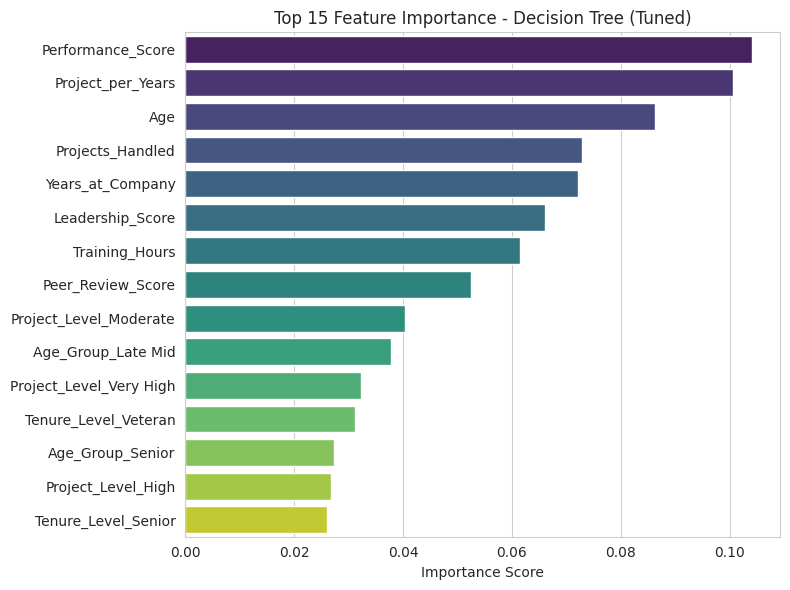

In [ ]:
# --- Feature Importance: Random Forest Tuned ---
model = rf_best

# --- Feature Importance ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# tampilkan 15 teratas
top_features = feature_importance.head(15)
display(top_features)

# visualisasi
plt.figure(figsize=(8,6))
sns.barplot(y='Feature', x='Importance', data=top_features, palette='viridis')
plt.title('Top 15 Feature Importance - Decision Tree (Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

🔹RandomForest Tuned (RandomSearch) sebagai model utama\
🔹 Pertahankan Logistic Regression sebagai baseline interpretable model\
🔹 Eksperimen threshold tuning (0.35–0.40) untuk RF & LogReg agar recall meningkat\
🔹 Pertimbangkan ensemble sederhana (LogReg + RF) jika mau optimalkan recall vs precision.

## SUMMARY OVERALL

# Stage 3 Evaluation

## A. Evaluasi Model

=== MODEL EVALUATION REPORT ===

Accuracy   | Train: 0.948 | Test: 0.707
Precision  | Train: 0.992 | Test: 0.500
Recall     | Train: 0.904 | Test: 0.164
F1-Score   | Train: 0.946 | Test: 0.247
ROC-AUC    | Train: 0.997 | Test: 0.506
PRC-AUC    | Train: 0.997 | Test: 0.347


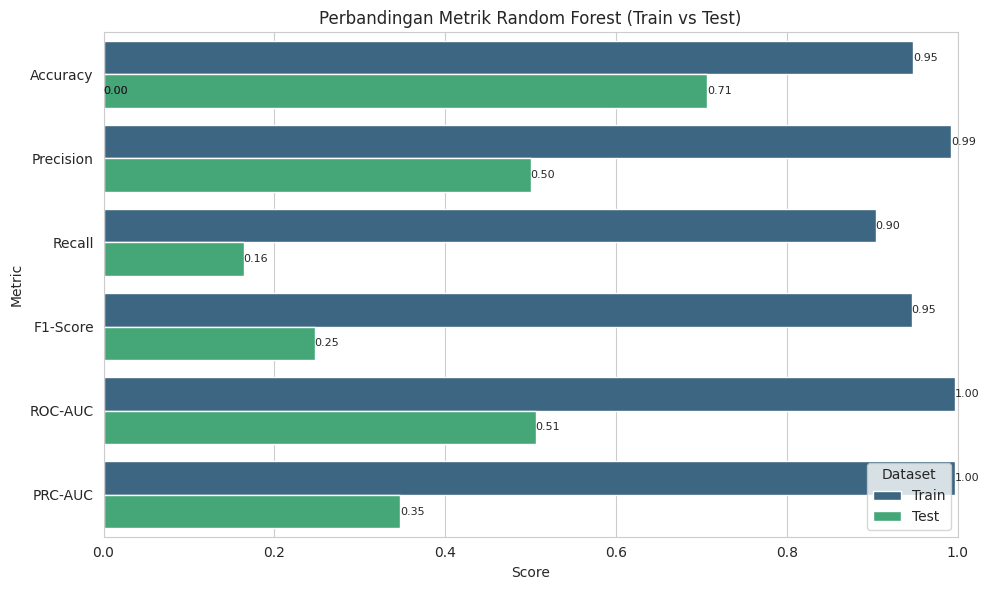

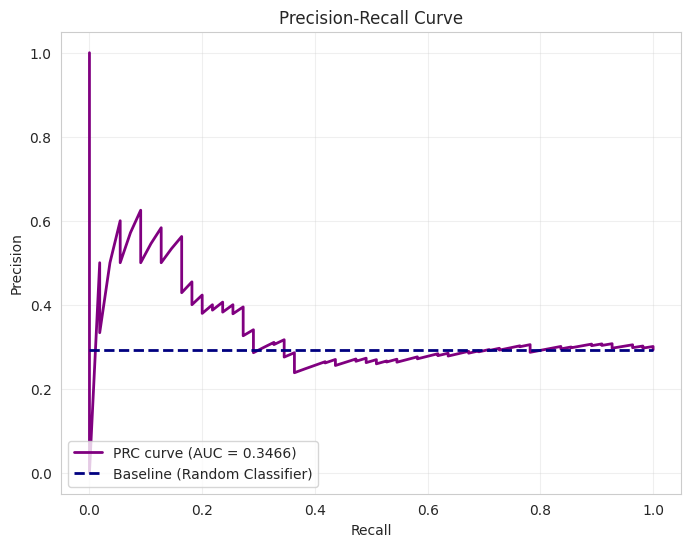

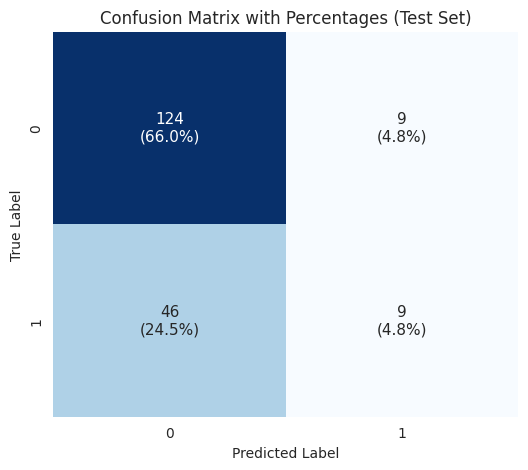


=== ERROR BREAKDOWN ===
    Error Type  Count Percentage
 True Negative    124     65.96%
False Negative     46     24.47%
 True Positive      9      4.79%
False Positive      9      4.79%

=== SIMULATION (500 Employees) ===
    Error Type  Count Percentage
 True Negative    342      68.4%
False Negative    112      22.4%
 True Positive     27       5.4%
False Positive     19       3.8%


In [ ]:
# =====================================================
# FINAL MODEL EVALUATION & ERROR ANALYSIS
# =====================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# === MODEL FINAL ===
model_final = rf_best  # hasil tuning terbaik

# === PREDIKSI ===
y_pred_train = model_final.predict(X_train_bal)
y_pred_test = model_final.predict(X_test)
y_pred_proba_train = model_final.predict_proba(X_train_bal)[:, 1]
y_pred_proba_test = model_final.predict_proba(X_test)[:, 1]

# === HITUNG METRIK ===
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PRC-AUC"],
    "Train": [
        accuracy_score(y_train_bal, y_pred_train),
        precision_score(y_train_bal, y_pred_train, zero_division=0),
        recall_score(y_train_bal, y_pred_train),
        f1_score(y_train_bal, y_pred_train),
        roc_auc_score(y_train_bal, y_pred_proba_train),
        average_precision_score(y_train_bal, y_pred_proba_train)
    ],
    "Test": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test, zero_division=0),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_pred_proba_test),
        average_precision_score(y_test, y_pred_proba_test)
    ]
}

df_metrics = pd.DataFrame(metrics).round(3)

# === TAMPILKAN SECARA VERTIKAL ===
print("=== MODEL EVALUATION REPORT ===\n")
for i, row in df_metrics.iterrows():
    print(f"{row['Metric']:<10} | Train: {row['Train']:.3f} | Test: {row['Test']:.3f}")

# === VISUALISASI ===
plt.figure(figsize=(10, 6))
df_melted = df_metrics.melt('Metric', var_name='Dataset', value_name='Score')
sns.barplot(x='Score', y='Metric', hue='Dataset', data=df_melted, palette='viridis')
plt.title('Perbandingan Metrik Random Forest (Train vs Test)')
plt.xlim(0, 1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.2f}',
                       (p.get_x() + p.get_width(), p.get_y() + 0.2),
                       ha='left', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# =====================================================
# PRECISION-RECALL CURVE
# =====================================================
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_test)
pr_auc = average_precision_score(y_test, y_pred_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2,
         label=f'PRC curve (AUC = {pr_auc:.4f})')
plt.plot([0, 1], [sum(y_test)/len(y_test)]*2, color='navy', lw=2, linestyle='--',
         label='Baseline (Random Classifier)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

# =====================================================
# CONFUSION MATRIX (DENGAN PERSENTASE)
# =====================================================
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm / np.sum(cm) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_percent.flatten())]).reshape(cm.shape),
    fmt='',
    cmap='Blues',
    cbar=False,
    annot_kws={"size": 11}
)
plt.title("Confusion Matrix with Percentages (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =====================================================
# 🧩 ERROR ANALYSIS
# =====================================================
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test,
    'probability_eligible': y_pred_proba_test
}, index=X_test.index)

# Tentukan tipe kesalahan
error_df['error_type'] = np.select(
    [
        (error_df['actual'] == 1) & (error_df['predicted'] == 1),
        (error_df['actual'] == 0) & (error_df['predicted'] == 0),
        (error_df['actual'] == 1) & (error_df['predicted'] == 0),
        (error_df['actual'] == 0) & (error_df['predicted'] == 1)
    ],
    ['True Positive', 'True Negative', 'False Negative', 'False Positive'],
    default='Unknown'
)

error_summary = (
    error_df['error_type']
    .value_counts()
    .rename_axis('Error Type')
    .reset_index(name='Count')
)
error_summary['Percentage'] = (
    (error_summary['Count'] / len(error_df) * 100).round(2).astype(str) + '%'
)

print("\n=== ERROR BREAKDOWN ===")
print(error_summary.to_string(index=False))

# =====================================================
# SIMULASI 500 KARYAWAN
# =====================================================
n = 500
if len(error_df) != n:
    sampled_df = error_df.sample(n=n, replace=True, random_state=42)
else:
    sampled_df = error_df.copy()

sim_summary = (
    sampled_df['error_type']
    .value_counts()
    .rename_axis('Error Type')
    .reset_index(name='Count')
)
sim_summary['Percentage'] = (
    (sim_summary['Count'] / len(sampled_df) * 100).round(2).astype(str) + '%'
)

print("\n=== SIMULATION (500 Employees) ===")
print(sim_summary.to_string(index=False))

Simulation diatas dari dataset secara random, jadi bisa jadi beda dg perhitungan biasa

=== MODEL EVALUATION REPORT ===


,Metric,Train,Test
0,Accuracy,0.948,0.707
1,Precision,0.992,0.500
2,Recall,0.904,0.164
3,F1-Score,0.946,0.247
4,ROC-AUC,0.997,0.506
5,PRC-AUC,0.997,0.347


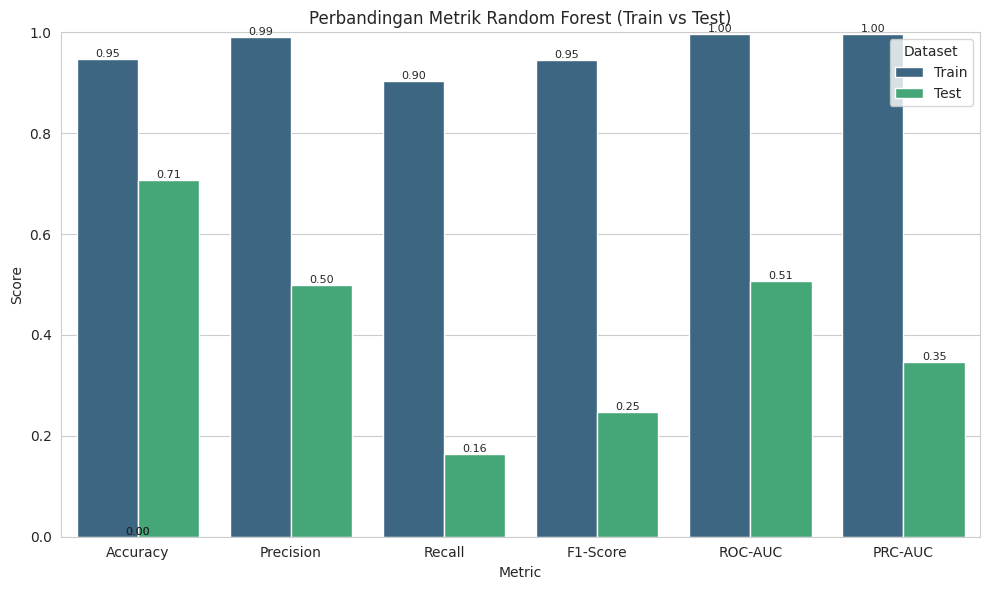

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === MODEL FINAL ===
model_final = rf_best  # hasil tuning terbaik

# === PREDIKSI ===
y_pred_train = model_final.predict(X_train_bal)
y_pred_test = model_final.predict(X_test)
y_pred_proba_train = model_final.predict_proba(X_train_bal)[:, 1]
y_pred_proba_test = model_final.predict_proba(X_test)[:, 1]

# === HITUNG METRIK ===
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PRC-AUC"],
    "Train": [
        accuracy_score(y_train_bal, y_pred_train),
        precision_score(y_train_bal, y_pred_train, zero_division=0),
        recall_score(y_train_bal, y_pred_train),
        f1_score(y_train_bal, y_pred_train),
        roc_auc_score(y_train_bal, y_pred_proba_train),
        average_precision_score(y_train_bal, y_pred_proba_train)
    ],
    "Test": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test, zero_division=0),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_pred_proba_test),
        average_precision_score(y_test, y_pred_proba_test)
    ]
}

df_metrics = pd.DataFrame(metrics)
print("=== MODEL EVALUATION REPORT ===")
display(df_metrics.round(3))

# === VISUALISASI METRIK ===
plt.figure(figsize=(10, 6))
df_melted = df_metrics.melt('Metric', var_name='Dataset', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Dataset', data=df_melted, palette='viridis')
plt.title('Perbandingan Metrik Random Forest (Train vs Test)')
plt.ylim(0, 1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


PRC-AUC Score: 0.3466


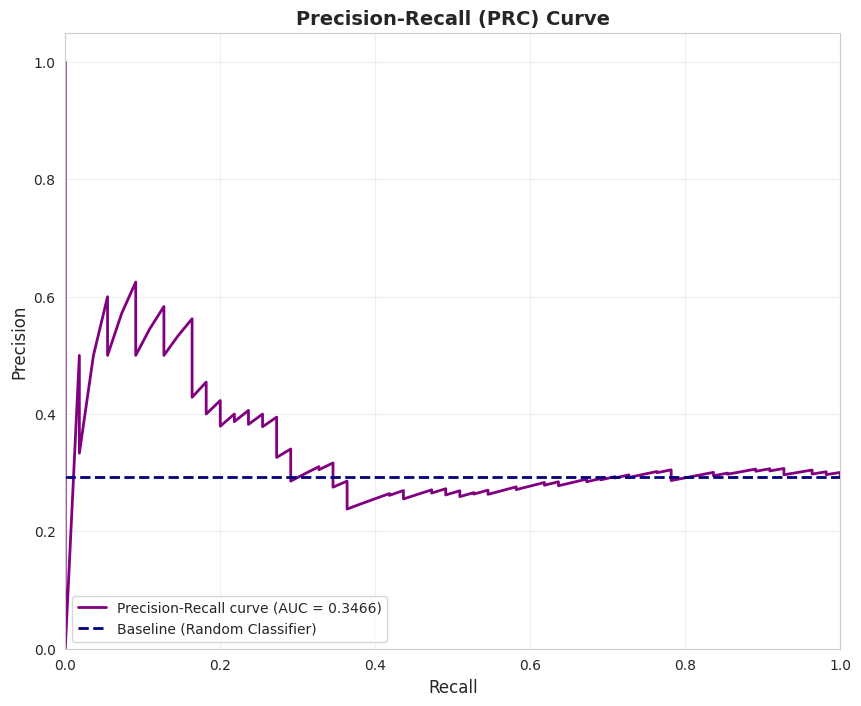

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# === Hitung Precision-Recall curve ===
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_test)
pr_auc = average_precision_score(y_test, y_pred_proba_test)

print(f"PRC-AUC Score: {pr_auc:.4f}")

# === Plot Precision-Recall Curve ===
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='purple', lw=2,
         label=f'Precision-Recall curve (AUC = {pr_auc:.4f})')
plt.plot([0, 1], [sum(y_test)/len(y_test)]*2, color='navy', lw=2, linestyle='--',
         label='Baseline (Random Classifier)')

# === Kustomisasi plot ===
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall (PRC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#bikin datafram hasil model terpilih
df_results = pd.DataFrame({
    "Employee_ID": X_test.index,
    "Actual": y_test,
    "Predicted": y_pred_test,
    "Probability": y_pred_proba_test,
})

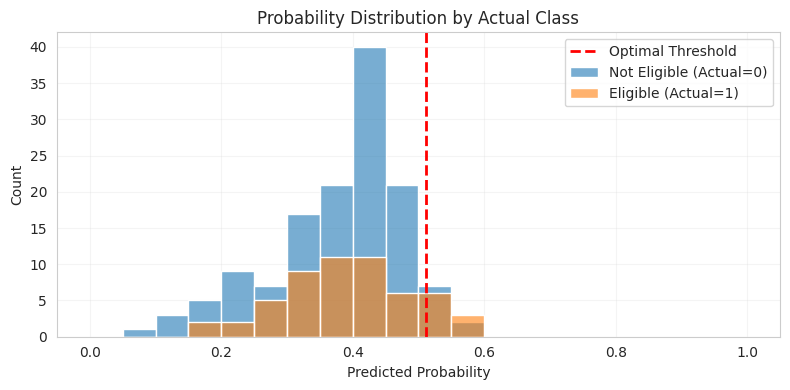

Optimal threshold (Youden's J): 0.512


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve

# Hitung optimal threshold
fpr, tpr, thresholds = roc_curve(df_results["Actual"], df_results["Probability"])
youden_index = tpr - fpr
optimal_threshold = thresholds[youden_index.argmax()]

# Buat bins untuk histogram (misal setiap 0.05)
bins = np.arange(0, 1.05, 0.05)

# Plot histogram tidak stacked
plt.figure(figsize=(8, 4))
sns.histplot(
    df_results[df_results["Actual"] == 0]["Probability"],
    bins=bins,
    color="#1f77b4",
    label="Not Eligible (Actual=0)",
    alpha=0.6,
    multiple="dodge"  # bar berdampingan, bukan stacked
)
sns.histplot(
    df_results[df_results["Actual"] == 1]["Probability"],
    bins=bins,
    color="#ff7f0e",
    label="Eligible (Actual=1)",
    alpha=0.6
)

# Garis threshold optimal
plt.axvline(optimal_threshold, color="red", linestyle="--", linewidth=2, label="Optimal Threshold")

# Label dan style
plt.title("Probability Distribution by Actual Class", fontsize=12)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Optimal threshold (Youden's J): {optimal_threshold:.3f}")


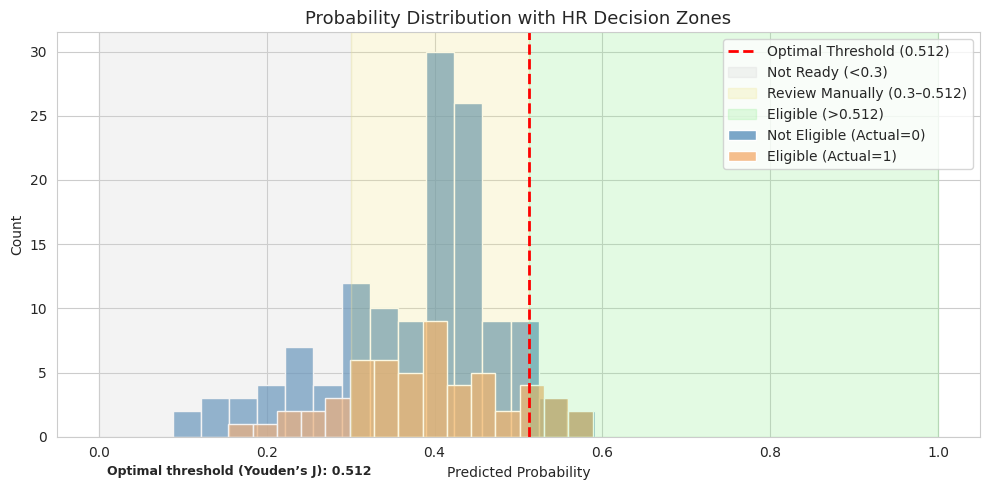

In [ ]:
#Beda warna threshold

import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot distribusi probabilitas
plt.figure(figsize=(10,5))
sns.histplot(df_results[df_results["Actual"]==0]["Probability"],
             bins=15, color="steelblue", label="Not Eligible (Actual=0)", alpha=0.7)
sns.histplot(df_results[df_results["Actual"]==1]["Probability"],
             bins=15, color="sandybrown", label="Eligible (Actual=1)", alpha=0.7)

# --- Tambahkan garis threshold optimal
threshold = 0.512
plt.axvline(threshold, color="red", linestyle="--", linewidth=2, label="Optimal Threshold (0.512)")

# --- Tambahkan zona interpretasi bisnis
plt.axvspan(0.0, 0.3, color="lightgrey", alpha=0.25, label="Not Ready (<0.3)")
plt.axvspan(0.3, threshold, color="khaki", alpha=0.25, label="Review Manually (0.3–0.512)")
plt.axvspan(threshold, 1.0, color="lightgreen", alpha=0.25, label="Eligible (>0.512)")

# --- Label & tampilan
plt.title("Probability Distribution with HR Decision Zones", fontsize=13)
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.text(0.01, -3, f"Optimal threshold (Youden’s J): {threshold:.3f}", fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


#### Menentukan Prioritas Review Eligibility

| Error Type                 | % of Employees | Est. Count (of 500) | **Probability Range**     | Category           | Interpretation                                              | **Key Action for HR**                            |
| -------------------------- | -------------- | ------------------- | --------------------------------- | ------------------ | ----------------------------------------------------------- | ------------------------------------------------ |
| TP  | 24.4%          | 122                 | **> 0.70**                        | Confirmed Eligible | Strong confidence — high likelihood of promotion readiness  | Proceed to promotion review / fast-track         |
| FN| 4.8%           | 24                  | **0.40 – 0.50 (below threshold)** | Missed Potential   | Model missed some actual high performers near the threshold | Manual review — may be strong performers         |
| FP| 4.8%           | 24                  | **0.50 – 0.65 (above threshold)** | Overestimated      | Predicted eligible, but actual data does not support it     | Validate data completeness / performance records |
| TN | 66%            | 330                 | **< 0.40**                        | Not Ready          | Consistently low probability — unlikely promotion-ready     | No immediate action needed                       |


In [ ]:
# Create error analysis dataframe
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_test,
    'probability_eligible': y_pred_proba_test
}, index=X_test.index)  # Use X_test.index instead of X_test_scaled.index

# Add original features for analysis
error_df = pd.concat([error_df, pd.DataFrame(X_test_scaled,
                    columns=[f'feature_{i}' for i in range(X_test_scaled.shape[1])])], axis=1)

# Classify errors
error_df['error_type'] = 'Correct'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'error_type'] = 'False Positive'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 1), 'error_type'] = 'True Positive'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 0), 'error_type'] = 'True Negative'

print(f"\n ERROR BREAKDOWN:")
print(error_df['error_type'].value_counts())


 ERROR BREAKDOWN:
error_type
Correct           148
True Negative     124
False Negative     46
True Positive       9
False Positive      9
Name: count, dtype: int64


##### Contoh untuk Dashboard HR

In [ ]:
#menambahkan kolom kategori dan key action
# Threshold baru berdasarkan Youden's J
optimal_threshold = 0.512

# Update predicted label berdasarkan threshold baru
df_results["Predicted_New"] = (df_results["Probability"] >= optimal_threshold).astype(int)


# Kategorisasi hasil
def categorize(row):
    if row["Actual"] == 1 and row["Predicted"] == 0:
        return "Missed Potential"
    elif row["Actual"] == 1 and row["Predicted"] == 1:
        return "Confirmed Eligible"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "Overestimated"
    else:
        return "Not Ready"

df_results["Category"] = df_results.apply(categorize, axis=1)

# Tambahkan rekomendasi aksi HR singkat
actions = {
    "Confirmed Eligible": "Proceed to promotion review / fast-track",
    "Missed Potential": "Manual review — may be strong performer",
    "Overestimated": "Recheck data completeness / validation",
    "Not Ready": "No immediate action needed",
}

df_results["HR_Action"] = df_results["Category"].map(actions)

# Tampilkan sample hasil
df_results[["Employee_ID", "Probability", "Predicted", "Category", "HR_Action"]].sample(5)




,Employee_ID,Probability,Predicted,Category,HR_Action
128,128,0.418383,0,Not Ready,No immediate action needed
38,38,0.449893,0,Missed Potential,Manual review — may be strong performer
151,151,0.453461,0,Not Ready,No immediate action needed
483,483,0.318358,0,Not Ready,No immediate action needed
115,115,0.406744,0,Not Ready,No immediate action needed


Alur yang Disarankan di Dashboard :

1. Summary metrics (accuracy, precision, recall, ROC-AUC, PR-AUC)

2. Category distribution chart (TP / FP / FN / TN)

3. Interactive table dengan filter kategori + search by employee ID

4. Insight panel — saran tindakan per kategori

## B. Explainability (SHAP)

Cocok untuk model Tree-based (Decision Tree, Random Forest, AdaBoost, XGBoost)

Makna:

Semakin tinggi nilai SHAP → semakin besar pengaruh fitur ke hasil prediksi.

Warna merah = dorong promosi, biru = menurunkan kemungkinan promosi.


=== SHAP EXPLAINABILITY ===


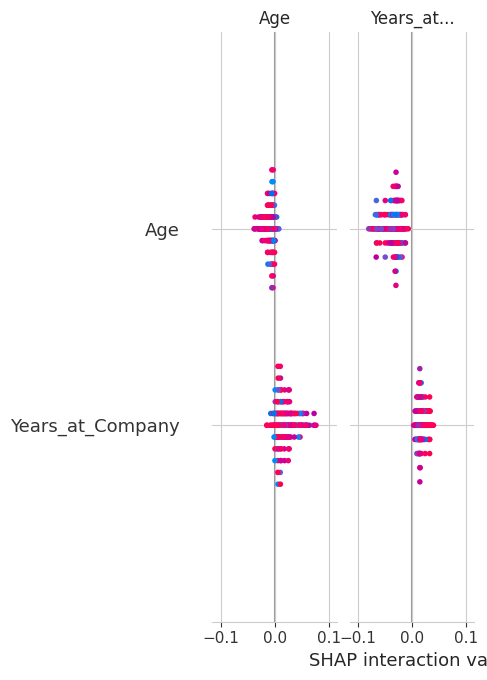

In [ ]:
# === 2. MODEL EXPLAINABILITY (SHAP) ===
import shap
import numpy as np
import pandas as pd

print("\n=== SHAP EXPLAINABILITY ===")

# Pastikan data test berbentuk DataFrame agar kolom dikenali
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Buat explainer (otomatis mendukung Tree model seperti DecisionTree, RF)
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_df)

# Cek bentuk shap_values
if isinstance(shap_values, list):
    # Binary classifier -> ambil shap untuk kelas 1 (positif)
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# --- Summary Plot (Feature Importance versi SHAP) ---
shap.summary_plot(
    shap_values_to_plot,
    X_test_df,
    feature_names=X_test_df.columns,
    plot_type="bar"
)


In [ ]:
import shap
import numpy as np

print("\n=== SHAP Force Plot - Safest Approach ===")
shap.initjs()

# Cek struktur SHAP values
print("Analyzing SHAP values structure...")

if isinstance(shap_values_to_plot, list):
    print(f"SHAP values is a list with {len(shap_values_to_plot)} elements")
    for i, arr in enumerate(shap_values_to_plot):
        print(f"  Element {i} shape: {arr.shape}")

    # Gunakan class 1, instance 0
    shap_vals = shap_values_to_plot[1][0]
else:
    shap_array = np.array(shap_values_to_plot)
    print(f"SHAP values shape: {shap_array.shape}")
    if len(shap_array.shape) == 3:
        shap_vals = shap_array[0, :, 1]  # instance 0, semua features, class 1
    elif len(shap_array.shape) == 2:
        shap_vals = shap_array[0, :]  # instance 0, semua features
    else:
        shap_vals = shap_array[0]  # instance 0

# Expected value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_val = explainer.expected_value[1]
else:
    expected_val = explainer.expected_value

print(f"Final SHAP values length: {len(shap_vals)}")
print(f"Number of features: {len(X_test_df.columns)}")

# Plot
shap.force_plot(
    expected_val,
    shap_vals,
    X_test_df.iloc[0].values,
    feature_names=X_test_df.columns.tolist()
)


=== SHAP Force Plot - Safest Approach ===


Analyzing SHAP values structure...
SHAP values shape: (188, 27, 2)
Final SHAP values length: 27
Number of features: 27


In [ ]:
import shap
import numpy as np

print("\n=== SHAP Force Plot with .values Approach ===")
shap.initjs()

try:
    # Cek struktur shap_values_to_plot
    print(f"shap_values_to_plot type: {type(shap_values_to_plot)}")

    # Coba akses .values jika available
    if hasattr(shap_values_to_plot, 'values'):
        shap_values_data = shap_values_to_plot.values
        print(f"shap_values_to_plot.values shape: {shap_values_data.shape}")
    else:
        shap_values_data = shap_values_to_plot
        print(f"shap_values_to_plot shape: {np.array(shap_values_data).shape}")

    # Handle expected value
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_val = explainer.expected_value[1]  # Class 1
    else:
        expected_val = explainer.expected_value

    print(f"Expected value: {expected_val}")

    # Coba beberapa pendekatan berbeda
    if hasattr(shap_values_data, 'shape'):
        if len(shap_values_data.shape) == 3:
            # Format: [instances, features, classes]
            shap_vals = shap_values_data[0, :, 1]  # Instance 0, semua features, class 1
        elif len(shap_values_data.shape) == 2:
            # Format: [instances, features] atau [instances, classes]
            if shap_values_data.shape[1] == len(X_test_df.columns):
                shap_vals = shap_values_data[0, :]  # Instance 0, semua features
            else:
                shap_vals = shap_values_data[0, 1]  # Instance 0, class 1
        else:
            shap_vals = shap_values_data[0]  # Instance 0
    else:
        # Jika berupa list
        if isinstance(shap_values_data, list):
            shap_vals = shap_values_data[1][0]  # Class 1, instance 0
        else:
            shap_vals = shap_values_data[0]  # Instance 0

    print(f"Final SHAP values length: {len(np.array(shap_vals).flatten())}")
    print(f"Number of features: {len(X_test_df.columns)}")

    # Force plot dengan .values
    shap.force_plot(
        expected_val,
        shap_vals,
        X_test_df.iloc[0:1],  # Gunakan 1 baris sebagai DataFrame
        plot_cmap="DrDb",
        matplotlib=False
    )

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


=== SHAP Force Plot with .values Approach ===


shap_values_to_plot type: <class 'numpy.ndarray'>
shap_values_to_plot shape: (188, 27, 2)
Expected value: 0.49999999999999806
Final SHAP values length: 27
Number of features: 27


In [ ]:
import shap
import numpy as np

print("\n=== SHAP Force Plot - Correct Structure ===")
shap.initjs()

try:
    # Struktur: (188 instances, 27 features, 2 classes)
    shap_values_data = shap_values_to_plot  # Shape: (188, 27, 2)

    # Expected value untuk class 1
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_val = explainer.expected_value[1]  # Class 1
    else:
        expected_val = explainer.expected_value

    print(f"SHAP values shape: {shap_values_data.shape}")
    print(f"Expected value: {expected_val}")

    # Ambil instance pertama, semua features, class 1
    shap_vals_instance0_class1 = shap_values_data[0, :, 1]  # Instance 0, semua features, class 1

    # Features untuk instance pertama
    features_instance0 = X_test_df.iloc[0]

    print(f"SHAP values untuk plotting: {shap_vals_instance0_class1.shape}")
    print(f"Features untuk plotting: {features_instance0.shape}")

    # Force plot
    shap.force_plot(
        expected_val,
        shap_vals_instance0_class1,  # Shape: (27,)
        features_instance0,          # Shape: (27,)
        feature_names=X_test_df.columns.tolist(),
        matplotlib=False
    )

    print("Force plot berhasil dibuat!")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


=== SHAP Force Plot - Correct Structure ===


SHAP values shape: (188, 27, 2)
Expected value: 0.49999999999999806
SHAP values untuk plotting: (27,)
Features untuk plotting: (27,)
Force plot berhasil dibuat!


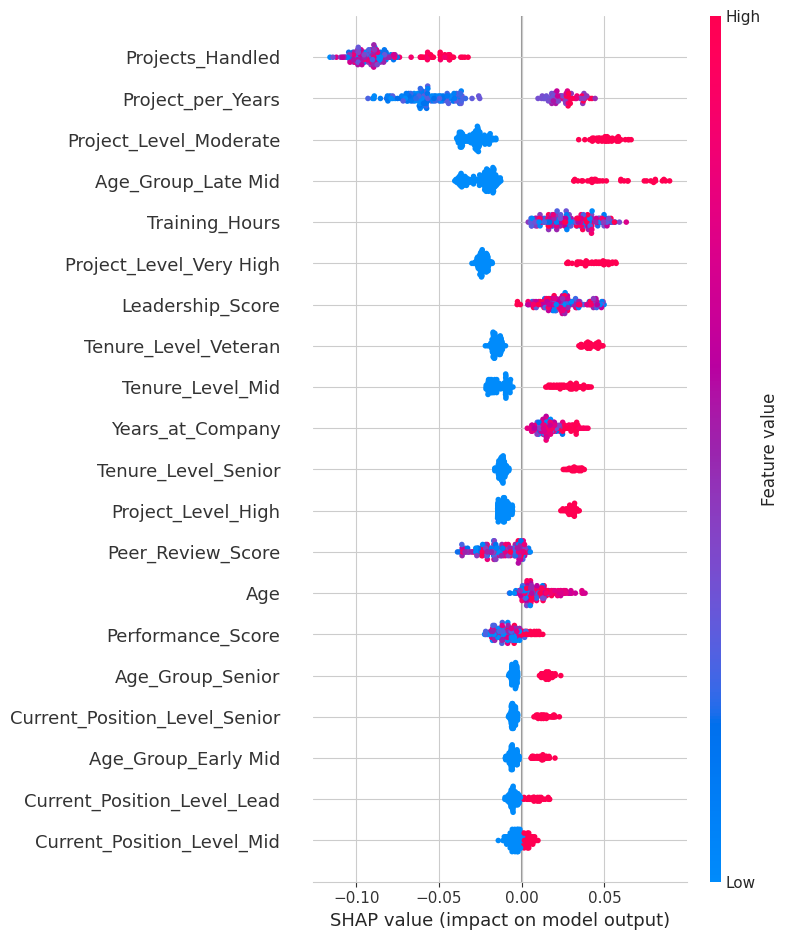

In [ ]:
# Instance ke-10
instance_idx = 10
shap.force_plot(
    expected_val,
    shap_values_data[instance_idx, :, 1],
    X_test_df.iloc[instance_idx],
    feature_names=X_test_df.columns.tolist()
)

# Summary plot untuk class 1
shap.summary_plot(shap_values_data[:, :, 1], X_test_df, show=False)

Pengaruh Performance_Score terhadap promosi tidak seragam di seluruh data — mungkin tergantung fitur lain (interaksi). - Titik merah di kiri → nilai performa tinggi menurunkan peluang promosi.

Kalau mayoritas karyawan berperforma tinggi tapi tidak dipromosikan (karena kuota promosi terbatas), model bisa “belajar” bahwa performa tinggi tidak selalu berarti promosi.

Pendorong Promosi (SHAP +)

* Projects_Handled, Peer_Review_Score, Leadership_Score → kontribusi positif kuat
* Training_Hours → sedikit pengaruh positif

Penghambat Promosi (SHAP –):
* Age_Group_Late Mid, Project_Level_Moderate → dampak negatif dominan
* Age, Training_Level_Low, Project_per_Years → menurunkan skor promosi

 Insight Bisnis

Karyawan yang cenderung dipromosikan:
* Performance tinggi
* Project & peer review bagus
* Leadership kuat
* Training memadai

Faktor penghambat:
* Usia “Late Mid” (mungkin stagnasi karier)
* Level project moderat atau training rendah

 Rekomendasi HR

A. Merit-Based Promotion: Fokuskan promosi pada performance & leadership, bukan usia. \
B. Career Path by Age:
* Late Mid → beri penghargaan non-promosi (bonus, proyek khusus).
* Junior → program percepatan karier\

C. Project & Training:
Dorong proyek lintas fungsi dan training personalisasi sesuai level

In [ ]:
# Feature Importance from Random Forest Tuned
feature_importance = pd.DataFrame({
    'feature': [f'feature_{i}' for i in range(X_test_scaled.shape[1])],
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFEATURE IMPORTANCE (Random Forest Tuned):")
print(feature_importance.head(10))

# Permutation Importance (more reliable)
perm_importance = permutation_importance(rf_best, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'feature': [f'feature_{i}' for i in range(X_test_scaled.shape[1])],
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\nPERMUTATION IMPORTANCE:")
print(perm_df.head(10))


FEATURE IMPORTANCE (Random Forest Tuned):
       feature  importance
2    feature_2    0.104027
7    feature_7    0.100574
0    feature_0    0.086233
5    feature_5    0.072861
1    feature_1    0.072083
3    feature_3    0.066003
4    feature_4    0.061447
6    feature_6    0.052449
18  feature_18    0.040377
25  feature_25    0.037818


NameError: name 'permutation_importance' is not defined

In [ ]:
#Threshold Analysis & Business Impact
# Precision-Recall Tradeoff
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_test)

# Find optimal threshold (F1-maximizing)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\n THRESHOLD ANALYSIS:")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Precision at optimal: {precisions[optimal_idx]:.3f}")
print(f"Recall at optimal: {recalls[optimal_idx]:.3f}")
print(f"F1 at optimal: {f1_scores[optimal_idx]:.3f}")

# Try different thresholds for business context
thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"\n PERFORMANCE AT DIFFERENT THRESHOLDS:")
for thresh in thresholds_to_try:
    y_pred_adj = (y_pred_proba_test >= thresh).astype(int)
    adj_recall = recall_score(y_test, y_pred_adj)
    adj_precision = precision_score(y_test, y_pred_adj)
    print(f"Threshold {thresh}: Precision={adj_precision:.3f}, Recall={adj_recall:.3f}")


 THRESHOLD ANALYSIS:
Optimal threshold: 0.591
Precision at optimal: 0.000
Recall at optimal: 0.000
F1 at optimal: nan

 PERFORMANCE AT DIFFERENT THRESHOLDS:
Threshold 0.3: Precision=0.299, Recall=0.836
Threshold 0.4: Precision=0.271, Recall=0.473
Threshold 0.5: Precision=0.500, Recall=0.164
Threshold 0.6: Precision=0.000, Recall=0.000
Threshold 0.7: Precision=0.000, Recall=0.000


In [ ]:
# Analyze characteristics of different error types
error_analysis = error_df.groupby('error_type').agg({
    'probability_eligible': ['mean', 'std', 'count'],
    'actual': 'count'
}).round(3)

print(f"\n ERROR PATTERN ANALYSIS:")
print(error_analysis)

# Compare feature distributions for error types
print(f"\n FEATURE MEANS BY ERROR TYPE:")
feature_means_by_error = error_df.groupby('error_type').mean().T
print(feature_means_by_error)


 ERROR PATTERN ANALYSIS:
               probability_eligible              actual
                               mean    std count  count
error_type                                             
Correct                         NaN    NaN     0      0
False Negative                0.362  0.079    46     46
False Positive                0.539  0.030     9      9
True Negative                 0.369  0.094   124    124
True Positive                 0.540  0.025     9      9

 FEATURE MEANS BY ERROR TYPE:
error_type             Correct  False Negative  False Positive  True Negative  True Positive
actual                     NaN        1.000000        0.000000       0.000000       1.000000
predicted                  NaN        0.000000        1.000000       0.000000       1.000000
probability_eligible       NaN        0.361643        0.538534       0.368527       0.540118
feature_0             0.121094        0.183227        0.107981       0.280193      -0.600019
feature_1            -0.008228

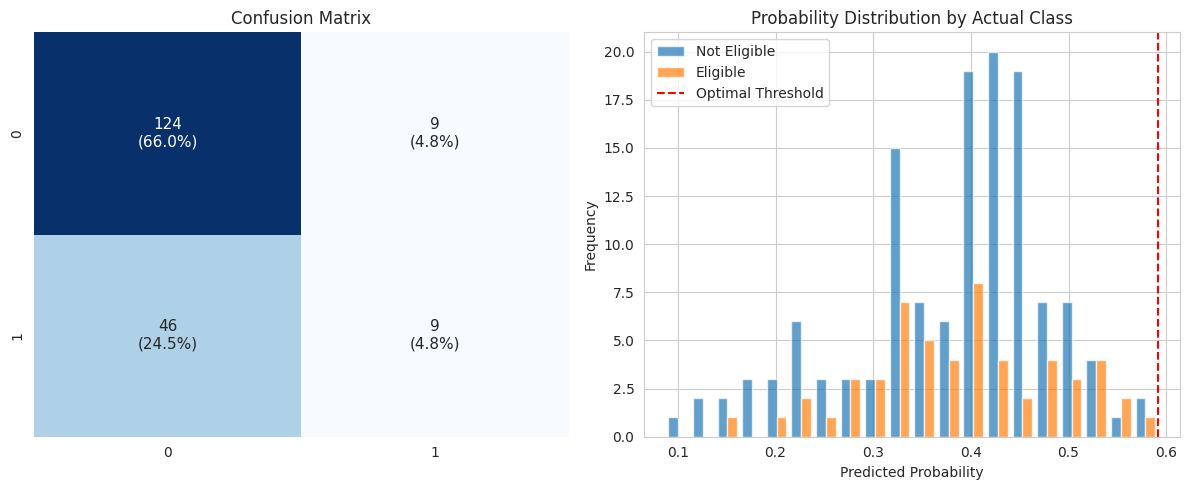

In [ ]:
# Create visualizations
fig, axes = plt.subplots(1,2 , figsize=(12, 5))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_test)
cm_percent = cm / np.sum(cm) * 100  # ubah ke persentase
sns.heatmap(
    cm,
    annot=np.array([f"{v}\n({p:.1f}%)" for v, p in zip(cm.flatten(), cm_percent.flatten())]).reshape(cm.shape),
    fmt='',
    cmap='Blues',
    cbar=False,
    annot_kws={"size": 11}
, ax=axes[0])
axes[0].set_title('Confusion Matrix')

# 2. Probability Distribution by Actual Class
axes[1].hist([y_pred_proba_test[y_test==0], y_pred_proba_test[y_test==1]],
               bins=20, alpha=0.7, label=['Not Eligible', 'Eligible'])
axes[1].axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Probability Distribution by Actual Class')
axes[1].legend()


plt.tight_layout()
plt.show()

## C. Fairness dan Bias Assessment

Cocok untuk semua model klasifikasi, terutama yang digunakan untuk HR, promosi, kredit, atau rekrutmen.

Makna:

Kalau perbedaan Recall antar grup besar (>0.2) → indikasi bias model.

Misal, model lebih sering mempromosikan Mid-level daripada Junior, padahal performa sama.

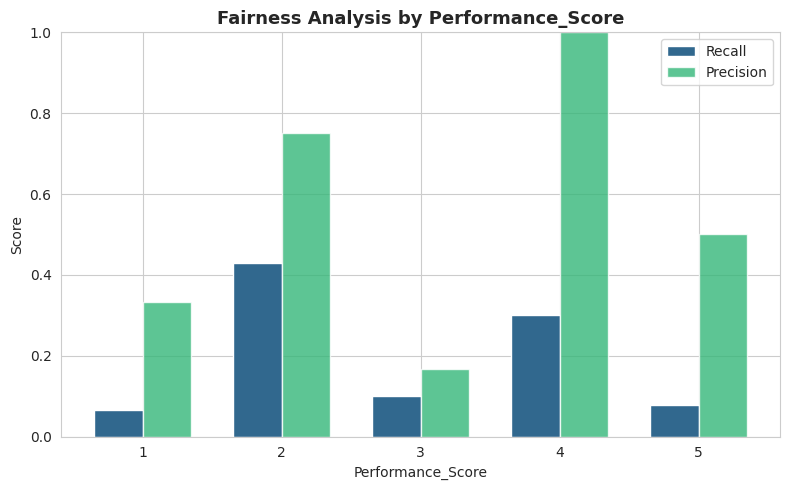


=== FAIRNESS REPORT ===


,Performance_Score,Recall,Precision
0,1,0.067,0.333
1,2,0.429,0.750
2,3,0.100,0.167
3,4,0.300,1.000
4,5,0.077,0.500


In [ ]:
# === 3. FAIRNESS & BIAS ASSESSMENT ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import recall_score, precision_score

# === FAIRNESS ANALYSIS BY PERFORMANCE SCORE ===

# Gunakan Performance_Score sebagai sensitive attribute
sensitive_test = X_test['Performance_Score']

# Pastikan kategori (integer)
sensitive_test_clean = sensitive_test.round().astype(int)

# Buat dataframe fairness
fairness_data = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred_test,
    'Group': sensitive_test_clean.reset_index(drop=True)
})

# Hitung metrik per group
fairness_metrics = []
for g in sorted(fairness_data['Group'].unique()):
    df_g = fairness_data[fairness_data['Group'] == g]
    fairness_metrics.append({
        'Performance_Score': g,
        'Recall': recall_score(df_g['Actual'], df_g['Predicted'], zero_division=0),
        'Precision': precision_score(df_g['Actual'], df_g['Predicted'], zero_division=0)
    })

df_fairness = pd.DataFrame(fairness_metrics)

# === Visualisasi side-by-side ===
plt.figure(figsize=(8, 5))
palette = sns.color_palette("viridis", 5)

x = np.arange(len(df_fairness['Performance_Score']))  # posisi tiap grup
width = 0.35  # lebar batang

plt.bar(x - width/2, df_fairness['Recall'], width, label='Recall', color=palette[1])
plt.bar(x + width/2, df_fairness['Precision'], width, label='Precision', color=palette[3], alpha=0.8)

# Tambahkan label
plt.xticks(x, df_fairness['Performance_Score'])
plt.xlabel('Performance_Score')
plt.ylabel('Score')
plt.title('Fairness Analysis by Performance_Score', fontsize=13, weight='bold')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FAIRNESS REPORT ===")
display(df_fairness.round(3))

# Preparation to Github - Streamlit

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

num_features = ["Age","Years_at_Company","Performance_Score","Leadership_Score",
                "Training_Hours","Projects_Handled","Peer_Review_Score"]
cat_features = ["Current_Position_Level"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [ ]:
X = df.drop(columns=["Promotion_Eligible", "Employee_ID"])
y = df["Promotion_Eligible"]

model.fit(X, y)

In [ ]:
!pip install cloudpickle

In [ ]:
import cloudpickle

with open("model2.pkl", "wb") as f:
    cloudpickle.dump(model, f)

In [ ]:
!pip freeze > requirements2.txt

In [ ]:
from google.colab import files
files.download('requirements2.txt')

In [ ]:
from google.colab import files
files.download("model2.pkl")

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
from pathlib import Path
import cloudpickle

model_path = Path("/content/model2.pkl")

with open(model_path, "rb") as f:
    model = cloudpickle.load(f)

# Cek feature names
if hasattr(model, "feature_names_in_"):
    feature_cols = model.feature_names_in_
    print("Feature columns:", feature_cols)
else:
    print("Model tidak punya attribute feature_names_in_")


In [ ]:
with open(model_path, "rb") as f:
    model = cloudpickle.load(f)

df["Predicted_Promotion"] = model.predict(df)

In [ ]:
# ============================================================
# 🚀 FINAL PIPELINE FIX (No 'Senior' Error)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import joblib

# ============================================================
# 1️⃣ LOAD DATA
# ============================================================
df = pd.read_csv('Rakamin Bootcamp - Dataset - Promotion Dataset.csv', sep=';')

# Imputasi numerik
num_cols = ['Age', 'Years_at_Company', 'Training_Hours',
            'Performance_Score', 'Leadership_Score',
            'Projects_Handled', 'Peer_Review_Score']
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Imputasi kategorikal
df['Current_Position_Level'] = df['Current_Position_Level'].fillna(df['Current_Position_Level'].mode()[0])

# Drop NA target
df.dropna(subset=['Promotion_Eligible'], inplace=True)
df['Promotion_Eligible'] = df['Promotion_Eligible'].astype(int)

# Drop kolom non-fitur
df = df.drop(columns=['Employee_ID'], errors='ignore')

# ============================================================
# 2️⃣ SPLIT
# ============================================================
X = df.drop('Promotion_Eligible', axis=1)
y = df['Promotion_Eligible']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# 3️⃣ PIPELINE
# ============================================================
num_features = ['Age', 'Years_at_Company', 'Training_Hours',
                'Performance_Score', 'Leadership_Score',
                'Projects_Handled', 'Peer_Review_Score']

# cek kolom kategorikal tersisa
cat_features = X_train.select_dtypes(include='object').columns.tolist()
print("🔍 Kolom kategorikal terdeteksi:", cat_features)

# pastikan pipeline mencakup semuanya
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

# model pipeline
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# ============================================================
# 4️⃣ SMOTE + FIT
# ============================================================
smote = SMOTE(random_state=42)
# SMOTE hanya bisa dipakai pada numerik, jadi encoding dulu manual dengan preprocessor
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train)

# Fit ulang pipeline ke data hasil SMOTE
pipeline.named_steps['model'].fit(X_train_res, y_train_res)

# ============================================================
# 5️⃣ SAVE MODEL
# ============================================================
joblib.dump(pipeline, 'model3.pkl')
print("✅ model3.pkl saved successfully — semua kategori sudah encoded.")


🔍 Kolom kategorikal terdeteksi: ['Current_Position_Level']
✅ model3.pkl saved successfully — semua kategori sudah encoded.
